In [1]:
import pandas as pd
import numpy as np
import formula_descriptors

# Load Cytotoxicity data

In [2]:
dataset = pd.read_csv("data/kim_model_data_for_ml.csv")
dataset

,Concentration,Compound,Cytotoxicity
0,0.1,PFHxS,3.100000e-18
1,5.0,PFHxS,2.940000e-07
2,10.0,PFHxS,2.270000e-05
3,20.0,PFHxS,1.494304e-03
4,40.0,PFHxS,7.297822e-02
...,...,...,...
721,160.0,Mix48,5.920338e+00
722,320.0,Mix48,8.215506e+01
723,640.0,Mix48,9.973611e+01
724,1280.0,Mix48,9.974000e+01


### Normalize

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Clip the upper to be 100
dataset['Cytotoxicity'] = dataset['Cytotoxicity'].clip(upper=100)

# Initialize the MinMaxScaler to scale values to the range [0, 1]
scaler = MinMaxScaler()

# Fit the scaler on the target variable and transform it
dataset["Cytotoxicity"] = scaler.fit_transform(dataset["Cytotoxicity"].values.reshape(-1, 1))

dataset["Concentration"] = dataset["Concentration"]/1000000

dataset

,Concentration,Compound,Cytotoxicity
0,1.000000e-07,PFHxS,3.100000e-20
1,5.000000e-06,PFHxS,2.940000e-09
2,1.000000e-05,PFHxS,2.270000e-07
3,2.000000e-05,PFHxS,1.494304e-05
4,4.000000e-05,PFHxS,7.297822e-04
...,...,...,...
721,1.600000e-04,Mix48,5.920338e-02
722,3.200000e-04,Mix48,8.215506e-01
723,6.400000e-04,Mix48,9.973611e-01
724,1.280000e-03,Mix48,9.974000e-01


# Generate training data (single ingredient only)

In [4]:
train = pd.read_csv("data/KIM_pubchem_hepg2_chemberta_embeddings.csv", index_col=0)
train = train[["compound"]+[ "emb_{}".format(i) for i in range(0,384) ]]
train.set_index('compound', inplace=True)
train

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
compound,,,,,,,,,,,,,,,,,,,,,
"2,4-DCP",-0.397415,-0.602348,-0.062367,0.509930,0.284185,0.299243,-0.391140,0.236416,-0.361170,0.209874,...,-0.367104,0.023312,0.062783,0.131439,0.039820,0.031435,-0.041275,-0.162000,-0.606179,-0.360052
"2,5-DCP",-0.142800,-0.564727,-0.069918,0.507382,0.439908,0.146263,-0.532931,0.136025,-0.221066,0.026536,...,-0.396367,0.060893,0.097783,0.170509,-0.183774,0.054095,-0.056161,-0.240935,-0.729859,-0.415152
pPB,0.064969,-0.370057,0.395895,0.285961,0.323424,0.265168,-0.176272,0.240052,-0.345505,-0.173970,...,-0.104164,0.169499,0.229696,0.296413,-0.099188,-0.412370,-0.357306,-0.185529,-0.618633,-0.182249
bPB,0.030381,-0.484868,0.293769,0.250188,0.142011,0.313457,-0.126543,0.293458,-0.487207,0.026566,...,-0.187763,0.019691,0.275738,0.214475,-0.201018,-0.148579,-0.435028,-0.267638,-0.517660,-0.089917
BP-3,-0.181222,-0.568535,-0.006115,0.321796,0.241850,0.061764,-0.337294,0.041484,-0.065370,0.207262,...,-0.027794,0.296864,0.084269,0.011656,-0.208684,-0.366786,-0.081210,-0.369623,-0.244868,-0.344598
TCS,-0.222955,-0.461202,-0.084986,0.292003,0.249321,0.548037,0.088294,0.270400,0.156821,0.120465,...,-0.180233,0.192036,0.041122,0.141791,0.088449,0.354120,-0.215963,-0.084222,-0.798773,-0.371715
Pb,0.349405,0.150223,0.225028,0.159288,0.336907,-0.108670,-0.188379,0.602608,-0.236729,-0.315939,...,-0.000837,-0.027256,0.120374,-0.696434,0.116556,-0.117984,-0.293882,-0.320630,-0.525666,-0.241756
Cu,0.456590,-0.041548,0.037607,0.072938,-0.207355,-0.269939,-0.075668,0.126308,-0.576250,0.093287,...,-0.173878,0.067683,0.044728,-0.121903,-0.236400,0.075067,-0.229852,-0.220079,0.131329,-0.473357
Se,0.399701,0.071493,0.022442,0.066601,-0.304091,-0.240752,-0.070143,-0.023204,-0.412022,-0.030427,...,-0.189837,-0.177703,0.114857,0.002861,-0.347643,0.162264,-0.137043,-0.059859,0.210664,-0.548381


In [5]:
training_set = dataset.merge(train, left_on='Compound', right_index=True)
training_set

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,1.000000e-07,PFHxS,3.100000e-20,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
1,5.000000e-06,PFHxS,2.940000e-09,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
2,1.000000e-05,PFHxS,2.270000e-07,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
3,2.000000e-05,PFHxS,1.494304e-05,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
4,4.000000e-05,PFHxS,7.297822e-04,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,1.600000e-04,TBOEP,1.507378e-01,-0.194818,-0.116627,0.081457,0.452656,0.155732,-0.251266,-0.000327,...,-0.090644,-0.139753,-0.272811,0.168291,0.120954,-0.273340,0.158711,-0.080187,-0.489991,-0.102841
304,3.200000e-04,TBOEP,5.331098e-01,-0.194818,-0.116627,0.081457,0.452656,0.155732,-0.251266,-0.000327,...,-0.090644,-0.139753,-0.272811,0.168291,0.120954,-0.273340,0.158711,-0.080187,-0.489991,-0.102841
305,6.400000e-04,TBOEP,9.720049e-01,-0.194818,-0.116627,0.081457,0.452656,0.155732,-0.251266,-0.000327,...,-0.090644,-0.139753,-0.272811,0.168291,0.120954,-0.273340,0.158711,-0.080187,-0.489991,-0.102841
306,1.280000e-03,TBOEP,9.918885e-01,-0.194818,-0.116627,0.081457,0.452656,0.155732,-0.251266,-0.000327,...,-0.090644,-0.139753,-0.272811,0.168291,0.120954,-0.273340,0.158711,-0.080187,-0.489991,-0.102841


In [6]:
#X_train = np.array(training_set.drop(columns=["Compound", "Cytotoxicity"]))
#y_train = np.array(training_set.Cytotoxicity.values)

# Now generate test data

### load mixture mapping data

In [7]:
mixture_info = pd.read_json('data/mixture_data_for_mapping.json', orient='index')
mixture_info

,Compound Names,Smiles,Mole Fractions,Molecular Weights (g/mol)
Mix1,"[PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB, Hg, Cu, Se...",[C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(C(C(F)(F)F...,"[7.29, 20.36, 18.92, 16.71, 11.88, 0.72, 0.33,...","[438.2, 163.0, 20.74, 180.2, 194.23, 251.1, 24..."
Mix2,"[PFNA, PFOA, BP-3, TCS, pPB, Hg, Cd, Sb]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.3, 17.56, 26.52, 0.59, 31.49, 1.35, 0.1, 8...","[464.08, 414.07, 228.1, 289.54, 180.2, 251.1, ..."
Mix3,"[BP-3, bPB, Co, Cu, Pb, Cd, Se, Zn, Sb, Ni]","[COc1ccc(c(c1)O)C(=O)c1ccccc1, CCCCOC(=O)c1ccc...","[14.13, 11.92, 16.96, 0.33, 23.63, 0.05, 0.26,...","[228.1, 194.23, 129.84, 249.7, 278.0, 183.3, 1..."
Mix4,"[TEHP, TDCPP, EHDPHP, TPhP, TnBP, TCPP, TBOEP]","[CCCCC(COP(=O)(OCC(CCCC)CC)OCC(CCCC)CC)CC, ClC...","[26.29, 14.07, 8.58, 5.27, 16.56, 17.39, 11.85]","[434.63, 430.9, 362.4, 362.4, 326.3, 398.5, 39..."
Mix5,"[2,4-DCP, 2,5-DCP, pPB, bPB, BP-3, TCS, TnBP, ...","[Clc1ccc(c(c1)Cl)O, Clc1ccc(c(c1)O)Cl, CCCOC(=...","[19.06, 17.71, 15.65, 11.12, 13.18, 0.29, 9.71...","[163.0, 163.0, 180.2, 194.23, 228.1, 289.54, 3..."
Mix6,"[PFNA, PFOA, PFHxS, EHDPHP, TBOEP, TDCPP, TEHP...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.45, 17.74, 13.87, 10.22, 14.13, 16.77, 6.5...","[464.08, 414.07, 438.2, None, 398.5, 430.9, 43..."
Mix7,"[Co, Cu, Pb, Cd, Se, Zn, Sb, Hg, Ni]","[Cl[Co]Cl, [O-]S(=O)(=O)[O-], Cl[Pb]Cl, Cl[Cd]...","[22.72, 0.45, 31.65, 0.07, 0.35000000000000003...","[129.84, 249.7, 278.0, 183.3, 172.95, 287.6, 2..."
Mix8,"[Pb, Cd, Zn, Hg, TBOEP, TDCPP, TEHP]","[Cl[Pb]Cl, Cl[Cd]Cl, [O-]S(=O)(=O)[O-], C[Hg]C...","[39.88, 0.09, 25.5, 1.21, 12.58, 14.93, 5.8100...","[278.0, 183.3, 287.6, 251.1, 398.5, 430.9, 434..."
Mix9,"[PFNA, PFOA, PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[7.13, 8.76, 6.85, 19.13, 17.77, 15.7, 11.16, ...","[464.08, 414.07, 438.2, 163.0, 163.0, 180.2, 1..."
Mix10,"[PFNA, PFOA, PFHxS, Co, Cu, Se, Sb, Ni]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[12.82, 15.74, 12.31, 28.53, 0.56, 0.44, 7.25,...","[464.08, 414.07, 438.2, 129.84, 249.7, 172.95,..."


In [8]:
mixture_info = mixture_info.drop(index='Mix15')
mixture_info = mixture_info.drop(index='Mix3')

### Calculate formula molecular descriptors

In [9]:
mix_emb_df = formula_descriptors.formulate_descriptors(mixture_info, train)
mix_emb_df

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
Mix1,0.017663,-0.354645,0.157547,0.345691,0.303968,0.124019,-0.288906,0.280154,-0.306027,-0.062515,...,-0.193508,0.043516,0.131140,-0.009254,-0.048981,-0.113903,-0.211305,-0.255023,-0.579290,-0.286732
Mix2,0.117814,-0.392179,0.325258,0.280323,0.121552,0.117412,-0.346549,0.177150,-0.206843,-0.016464,...,-0.260283,0.206499,0.143621,0.060022,0.023183,-0.305010,-0.183249,-0.282676,-0.393770,-0.214948
Mix4,-0.023653,-0.243407,0.043845,0.379831,0.262073,-0.141625,-0.219336,0.104340,-0.188030,0.042161,...,-0.081537,0.042889,-0.063428,0.023369,0.187878,-0.363101,-0.042281,-0.102778,-0.514648,-0.236071
Mix5,-0.095152,-0.467871,0.065959,0.401184,0.277461,0.122237,-0.313066,0.168829,-0.306819,0.054300,...,-0.222234,0.106764,0.097319,0.149806,-0.040484,-0.179263,-0.165455,-0.209272,-0.571926,-0.298280
Mix6,0.213820,-0.330857,0.253005,0.369017,0.148568,-0.153192,-0.301138,0.091749,-0.169187,-0.026189,...,-0.263024,0.136391,0.011191,0.069944,0.177974,-0.265823,-0.097206,-0.262362,-0.442272,-0.269507
Mix7,0.357134,-0.068272,0.240897,0.125188,0.087895,-0.052353,-0.227838,0.363891,-0.302150,-0.094533,...,0.013175,-0.025643,0.131356,-0.157356,0.054062,-0.076036,-0.276445,-0.238706,-0.441791,-0.143794
Mix8,0.224677,-0.015432,0.122534,0.194670,0.117578,-0.178003,-0.176065,0.306163,-0.321108,-0.087601,...,-0.065052,0.026230,0.020568,-0.254215,0.060207,-0.139871,-0.186237,-0.219681,-0.354721,-0.328354
Mix9,-0.026416,-0.502313,0.178638,0.379128,0.227108,0.144857,-0.349968,0.158022,-0.262539,0.031842,...,-0.282465,0.127721,0.130642,0.150367,-0.047374,-0.143974,-0.166981,-0.271035,-0.515558,-0.292557
Mix10,0.358712,-0.323729,0.374456,0.228817,0.037617,0.003350,-0.360931,0.200003,-0.202685,-0.047016,...,-0.144673,0.038771,0.155051,0.104718,0.150737,-0.127794,-0.238981,-0.275647,-0.521351,-0.073918
Mix11,0.209795,-0.241105,0.164817,0.270838,0.156381,-0.052986,-0.288115,0.228517,-0.304679,-0.076489,...,-0.196620,0.076005,0.099868,-0.076340,-0.003960,-0.088003,-0.216947,-0.273562,-0.438716,-0.339802


In [10]:
testing_set = dataset.merge(mix_emb_df, left_on='Compound', right_index=True)
testing_set

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
99,1.000000e-07,Mix1,0.000102,0.017663,-0.354645,0.157547,0.345691,0.303968,0.124019,-0.288906,...,-0.193508,0.043516,0.131140,-0.009254,-0.048981,-0.113903,-0.211305,-0.255023,-0.579290,-0.286732
100,5.000000e-06,Mix1,0.000137,0.017663,-0.354645,0.157547,0.345691,0.303968,0.124019,-0.288906,...,-0.193508,0.043516,0.131140,-0.009254,-0.048981,-0.113903,-0.211305,-0.255023,-0.579290,-0.286732
101,1.000000e-05,Mix1,0.000182,0.017663,-0.354645,0.157547,0.345691,0.303968,0.124019,-0.288906,...,-0.193508,0.043516,0.131140,-0.009254,-0.048981,-0.113903,-0.211305,-0.255023,-0.579290,-0.286732
102,2.000000e-05,Mix1,0.000314,0.017663,-0.354645,0.157547,0.345691,0.303968,0.124019,-0.288906,...,-0.193508,0.043516,0.131140,-0.009254,-0.048981,-0.113903,-0.211305,-0.255023,-0.579290,-0.286732
103,4.000000e-05,Mix1,0.000841,0.017663,-0.354645,0.157547,0.345691,0.303968,0.124019,-0.288906,...,-0.193508,0.043516,0.131140,-0.009254,-0.048981,-0.113903,-0.211305,-0.255023,-0.579290,-0.286732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,1.600000e-04,Mix48,0.059203,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784
722,3.200000e-04,Mix48,0.821551,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784
723,6.400000e-04,Mix48,0.997361,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784
724,1.280000e-03,Mix48,0.997400,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784


In [11]:
#X_test = np.array(testing_set.drop(columns=["Compound", "Cytotoxicity"]))
#y_test = np.array(testing_set.Cytotoxicity.values)

# Make train/test splits at the sample level

In [12]:
altogether = pd.concat([training_set, testing_set], ignore_index=True)
altogether

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,1.000000e-07,PFHxS,3.100000e-20,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
1,5.000000e-06,PFHxS,2.940000e-09,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
2,1.000000e-05,PFHxS,2.270000e-07,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
3,2.000000e-05,PFHxS,1.494304e-05,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
4,4.000000e-05,PFHxS,7.297822e-04,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,-0.071761,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,1.600000e-04,Mix48,5.920338e-02,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784
689,3.200000e-04,Mix48,8.215506e-01,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784
690,6.400000e-04,Mix48,9.973611e-01,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784
691,1.280000e-03,Mix48,9.974000e-01,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,-0.152295,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784


In [13]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(altogether, test_size=0.2, random_state=42)

In [14]:
train

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
110,1.000000e-07,PFNA,9.000000e-87,0.373914,-0.408950,0.523637,0.304158,-0.077984,-0.002402,-0.485409,...,-0.615103,0.273715,0.152910,-0.015540,0.292429,-0.124365,-0.130913,-0.337992,-0.370422,-0.207204
82,8.000000e-05,Se,4.758596e-01,0.399701,0.071493,0.022442,0.066601,-0.304091,-0.240752,-0.070143,...,-0.189837,-0.177703,0.114857,0.002861,-0.347643,0.162264,-0.137043,-0.059859,0.210664,-0.548381
51,3.200000e-04,bPB,4.085018e-01,0.030381,-0.484868,0.293769,0.250188,0.142011,0.313457,-0.126543,...,-0.187763,0.019691,0.275738,0.214475,-0.201018,-0.148579,-0.435028,-0.267638,-0.517660,-0.089917
218,1.280000e-03,TCPP,9.797999e-01,0.079098,-0.417882,-0.124500,0.421929,0.147692,-0.170495,-0.353495,...,-0.296962,0.185041,0.008583,0.076728,0.276103,-0.354449,-0.244034,-0.197143,-0.657971,-0.432562
622,1.600000e-04,Mix41,3.147748e-02,0.236704,-0.170201,0.180753,0.292739,0.024314,-0.195873,-0.238314,...,-0.136894,0.094870,0.027317,0.113274,0.058623,-0.212368,-0.148033,-0.226217,-0.326381,-0.296904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.000000e-05,Cu,5.663040e-01,0.456590,-0.041548,0.037607,0.072938,-0.207355,-0.269939,-0.075668,...,-0.173878,0.067683,0.044728,-0.121903,-0.236400,0.075067,-0.229852,-0.220079,0.131329,-0.473357
106,3.200000e-04,TCS,1.000000e+00,-0.222955,-0.461202,-0.084986,0.292003,0.249321,0.548037,0.088294,...,-0.180233,0.192036,0.041122,0.141791,0.088449,0.354120,-0.215963,-0.084222,-0.798773,-0.371715
270,1.600000e-04,Mix1,3.910159e-02,0.017663,-0.354645,0.157547,0.345691,0.303968,0.124019,-0.288906,...,-0.193508,0.043516,0.131140,-0.009254,-0.048981,-0.113903,-0.211305,-0.255023,-0.579290,-0.286732
435,1.600000e-04,Mix20,1.230221e-05,0.219998,-0.241720,0.207464,0.293876,0.096316,-0.105608,-0.217396,...,-0.116309,0.131848,0.090465,0.185077,0.018654,-0.238215,-0.219892,-0.228079,-0.397236,-0.293347


In [15]:
test

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
381,3.200000e-04,Mix13,0.578401,0.102747,-0.266440,0.152150,0.369918,0.230967,-0.131164,-0.212363,...,-0.029613,0.102673,0.021080,0.137984,-0.016958,-0.344078,-0.091938,-0.266008,-0.396436,-0.208137
665,8.000000e-05,Mix46,0.012697,0.309455,-0.265269,0.174328,0.233152,0.093782,-0.115547,-0.269209,...,-0.075476,0.057839,0.090501,0.103458,0.063381,-0.174923,-0.247868,-0.247801,-0.466643,-0.227633
257,4.000000e-05,TBOEP,0.041896,-0.194818,-0.116627,0.081457,0.452656,0.155732,-0.251266,-0.000327,...,-0.090644,-0.139753,-0.272811,0.168291,0.120954,-0.273340,0.158711,-0.080187,-0.489991,-0.102841
338,6.400000e-04,Mix8,0.964789,0.224677,-0.015432,0.122534,0.194670,0.117578,-0.178003,-0.176065,...,-0.065052,0.026230,0.020568,-0.254215,0.060207,-0.139871,-0.186237,-0.219681,-0.354721,-0.328354
319,1.000000e-07,Mix7,0.021693,0.357134,-0.068272,0.240897,0.125188,0.087895,-0.052353,-0.227838,...,0.013175,-0.025643,0.131356,-0.157356,0.054062,-0.076036,-0.276445,-0.238706,-0.441791,-0.143794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8.000000e-05,Mix31,0.000224,0.262895,-0.272852,0.280607,0.241319,0.112830,-0.020998,-0.260751,...,0.018254,-0.058459,0.092575,0.144372,0.088894,-0.156745,-0.207126,-0.224271,-0.579511,-0.038076
24,1.000000e-05,"2,5-DCP",0.000034,-0.142800,-0.564727,-0.069918,0.507382,0.439908,0.146263,-0.532931,...,-0.396367,0.060893,0.097783,0.170509,-0.183774,0.054095,-0.056161,-0.240935,-0.729859,-0.415152
158,4.000000e-05,Co,0.000090,0.380191,-0.511575,0.386153,0.033707,0.122612,0.207646,-0.364274,...,0.035511,-0.252531,0.206112,0.088652,0.197240,0.200361,-0.424512,-0.198841,-0.970060,0.259789
521,4.000000e-05,Mix32,0.001858,0.151792,-0.309653,0.120565,0.297346,0.144529,-0.078096,-0.300286,...,-0.142509,-0.009245,0.014416,0.043766,0.190759,-0.183829,-0.191856,-0.154970,-0.658302,-0.154689


In [16]:
X_train = np.array(train.drop(columns=["Compound", "Cytotoxicity"]))
y_train = np.array(train.Cytotoxicity.values)

In [17]:
X_test = np.array(test.drop(columns=["Compound", "Cytotoxicity"]))
y_test = np.array(test.Cytotoxicity.values)

# Grid Search

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [19]:
import json

param_grid = {
    'n_estimators': [100, 200, 300, 400],  # Number of trees
    'max_depth': [None, 10, 20, 30, 40],  # Tree depth
#    'min_samples_split': [2, 4, 6, 8, 10],  # Minimum number of samples to split
#    'min_samples_leaf': [1, 2, 4, 6, 8],  # Minimum number of samples at a leaf
#    'max_features': ['sqrt', 'log2', None],  # Number of features to consider at every split
#    'bootstrap': [True, False],  # Bootstrap samples are used when building trees
    'criterion': ['squared_error', 'absolute_error'],  # Measure of the quality of a split
    'random_state':[42]
}

In [20]:
# Define the model
rf = RandomForestRegressor()

In [21]:
best_score = 0.0
best_params = None
model = None

# Gonna iterate and evaluate each combination of parameters
for params in ParameterGrid(param_grid):

    rf.set_params(**params)

    # Fit the model
    rf.fit(X_train, y_train)

    # Make predictions on the test set and evaluate
    y_pred = rf.predict(X_test)
    score = r2_score(y_test, y_pred)

    # Check if this is the best model so far and then store (I know this is elementary)
    if score > best_score:
        best_score = score
        best_params = params
        model = rf

In [78]:
print(f"Best Parameters: {best_params}")

Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'n_estimators': 100, 'random_state': 42}


In [ ]:
best =  RandomForestRegressor(criterion='absolute_error', max_depth=None, n_estimators=100, random_state=42)
model = best.fit(X_train, y_train)
model

# Load the model

In [22]:
import pickle

# Open the file in binary read mode ('rb')
with open("80_20_level_model.pkl", 'rb') as file:
    # Load the model from the file
    loaded_model = pickle.load(file)

In [27]:
#model = RandomForestRegressor()
#model.fit(X_train, y_train)

In [81]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
r2

0.9126254382400505

In [82]:
mean_absolute_error(y_test, y_pred)

0.05202276921025591

In [83]:
mean_squared_error(y_test, y_pred)

0.01374638747332399

In [84]:
np.sqrt(mean_squared_error(y_test, y_pred))

0.11724498911818786

In [85]:
len(y_test)

139

In [29]:
test

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
381,3.200000e-04,Mix13,0.578401,0.102747,-0.266440,0.152150,0.369918,0.230967,-0.131164,-0.212363,...,-0.029613,0.102673,0.021080,0.137984,-0.016958,-0.344078,-0.091938,-0.266008,-0.396436,-0.208137
665,8.000000e-05,Mix46,0.012697,0.309455,-0.265269,0.174328,0.233152,0.093782,-0.115547,-0.269209,...,-0.075476,0.057839,0.090501,0.103458,0.063381,-0.174923,-0.247868,-0.247801,-0.466643,-0.227633
257,4.000000e-05,TBOEP,0.041896,-0.194818,-0.116627,0.081457,0.452656,0.155732,-0.251266,-0.000327,...,-0.090644,-0.139753,-0.272811,0.168291,0.120954,-0.273340,0.158711,-0.080187,-0.489991,-0.102841
338,6.400000e-04,Mix8,0.964789,0.224677,-0.015432,0.122534,0.194670,0.117578,-0.178003,-0.176065,...,-0.065052,0.026230,0.020568,-0.254215,0.060207,-0.139871,-0.186237,-0.219681,-0.354721,-0.328354
319,1.000000e-07,Mix7,0.021693,0.357134,-0.068272,0.240897,0.125188,0.087895,-0.052353,-0.227838,...,0.013175,-0.025643,0.131356,-0.157356,0.054062,-0.076036,-0.276445,-0.238706,-0.441791,-0.143794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8.000000e-05,Mix31,0.000224,0.262895,-0.272852,0.280607,0.241319,0.112830,-0.020998,-0.260751,...,0.018254,-0.058459,0.092575,0.144372,0.088894,-0.156745,-0.207126,-0.224271,-0.579511,-0.038076
24,1.000000e-05,"2,5-DCP",0.000034,-0.142800,-0.564727,-0.069918,0.507382,0.439908,0.146263,-0.532931,...,-0.396367,0.060893,0.097783,0.170509,-0.183774,0.054095,-0.056161,-0.240935,-0.729859,-0.415152
158,4.000000e-05,Co,0.000090,0.380191,-0.511575,0.386153,0.033707,0.122612,0.207646,-0.364274,...,0.035511,-0.252531,0.206112,0.088652,0.197240,0.200361,-0.424512,-0.198841,-0.970060,0.259789
521,4.000000e-05,Mix32,0.001858,0.151792,-0.309653,0.120565,0.297346,0.144529,-0.078096,-0.300286,...,-0.142509,-0.009245,0.014416,0.043766,0.190759,-0.183829,-0.191856,-0.154970,-0.658302,-0.154689


In [30]:
mix_test = np.array(test.drop(columns=["Compound","Cytotoxicity"]))
mix_test_y = np.array(test["Cytotoxicity"].values)

# Train validation

In [71]:
train_predicted = model.predict(X_train)

In [72]:
r2_score(y_train, train_predicted)

0.9847926563768347

# Load File

In [75]:
import pickle

pkl_file = '80_20_level_model.pkl'

with open(pkl_file, 'wb') as file:
    pickle.dump(model, file)

In [27]:
import pickle

with open("80_20_level_model.pkl", 'rb') as f:
    model = pickle.load(f)

# Let's analyze some of this

In [28]:
features = np.array(altogether.drop(columns=["Compound", "Cytotoxicity"]))

In [29]:
features

array([[ 1.00000000e-07,  3.58371735e-01, -5.22580326e-01, ...,
        -5.11622369e-01, -3.52135330e-01, -5.01163840e-01],
       [ 5.00000000e-06,  3.58371735e-01, -5.22580326e-01, ...,
        -5.11622369e-01, -3.52135330e-01, -5.01163840e-01],
       [ 1.00000000e-05,  3.58371735e-01, -5.22580326e-01, ...,
        -5.11622369e-01, -3.52135330e-01, -5.01163840e-01],
       ...,
       [ 6.40000000e-04,  1.16371737e-01, -1.82404715e-01, ...,
        -2.70706311e-01, -5.86632837e-01, -2.54784172e-01],
       [ 1.28000000e-03,  1.16371737e-01, -1.82404715e-01, ...,
        -2.70706311e-01, -5.86632837e-01, -2.54784172e-01],
       [ 2.56000000e-03,  1.16371737e-01, -1.82404715e-01, ...,
        -2.70706311e-01, -5.86632837e-01, -2.54784172e-01]])

In [30]:
altogether["predicted_Cytotoxicity"] = model.predict(features)

In [31]:
test.Compound.unique()

array(['Mix13', 'Mix46', 'TBOEP', 'Mix8', 'Mix7', 'TCPP', 'Mix12', 'Zn',
       'Mix6', 'Ni', 'Mix25', 'Se', 'Mix18', 'Mix21', 'Mix48', 'Mix44',
       'Mix33', 'Mix34', 'Mix4', 'Mix42', 'EHDPHP', 'bPB', 'Mix23',
       'Mix19', 'Sb', 'Mix45', 'TCS', 'Mix11', 'TDCPP', 'Mix47', 'Cu',
       'Mix36', 'Mix38', 'Mix32', 'Mix2', 'Pb', 'PFHxS', 'Hg', 'Mix22',
       'Mix37', '2,5-DCP', 'TPhP', 'Mix30', 'Mix9', 'Mix39', 'PFNA',
       'Mix35', 'Mix41', 'PFOA', 'Mix5', 'BP-3', 'Co', 'Mix31', 'Mix14',
       'Mix1', 'pPB', 'Cd', 'TEHP', 'Mix20'], dtype=object)

In [32]:
altogether.Compound.unique()

array(['PFHxS', '2,4-DCP', '2,5-DCP', 'pPB', 'bPB', 'Hg', 'Cu', 'Se',
       'Pb', 'TCS', 'PFNA', 'PFOA', 'Sb', 'BP-3', 'Co', 'Ni', 'Zn', 'Cd',
       'TEHP', 'TCPP', 'TPhP', 'TDCPP', 'EHDPHP', 'TBOEP', 'Mix1', 'Mix2',
       'Mix4', 'Mix5', 'Mix6', 'Mix7', 'Mix8', 'Mix9', 'Mix11', 'Mix12',
       'Mix13', 'Mix14', 'Mix17', 'Mix18', 'Mix19', 'Mix20', 'Mix21',
       'Mix22', 'Mix23', 'Mix25', 'Mix28', 'Mix30', 'Mix31', 'Mix32',
       'Mix33', 'Mix34', 'Mix35', 'Mix36', 'Mix37', 'Mix38', 'Mix39',
       'Mix40', 'Mix41', 'Mix42', 'Mix44', 'Mix45', 'Mix46', 'Mix47',
       'Mix48'], dtype=object)

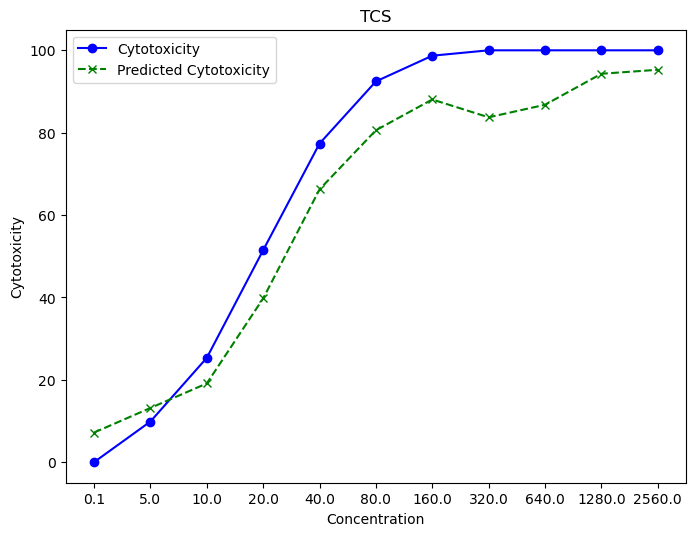

In [33]:
import matplotlib.pyplot as plt

compound_name = "TCS"

df = altogether[altogether["Compound"] == compound_name]
concentration = df["Concentration"]

# Plotting
fig, ax = plt.subplots(figsize=(8,6), dpi=100)
#plt.figure(figsize=(6,5))
plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='o', linestyle='-', label='Cytotoxicity')
plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')

#plt.title(compound_name)
plt.title(compound_name)
plt.xlabel('Concentration')
plt.ylabel('Cytotoxicity')
plt.legend()
#plt.savefig(f"/Users/shou626/Downloads/{compound_name}_newest.png", dpi=300, bbox_inches='tight')
plt.show()

In [34]:
altogether

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,predicted_Cytotoxicity
0,1.000000e-07,PFHxS,3.100000e-20,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164,0.000094
1,5.000000e-06,PFHxS,2.940000e-09,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164,0.000094
2,1.000000e-05,PFHxS,2.270000e-07,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164,0.000097
3,2.000000e-05,PFHxS,1.494304e-05,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164,0.000182
4,4.000000e-05,PFHxS,7.297822e-04,0.358372,-0.522580,0.389264,0.414959,0.214535,-0.307922,-0.231324,...,0.052392,-0.008861,0.285954,-0.129393,-0.211914,-0.112174,-0.511622,-0.352135,-0.501164,0.001262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,1.600000e-04,Mix48,5.920338e-02,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784,0.050875
689,3.200000e-04,Mix48,8.215506e-01,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784,0.254817
690,6.400000e-04,Mix48,9.973611e-01,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784,0.967680
691,1.280000e-03,Mix48,9.974000e-01,0.116372,-0.182405,0.108274,0.340779,0.386335,-0.049151,-0.263317,...,0.007668,0.049492,-0.192601,-0.000835,-0.117153,-0.138500,-0.270706,-0.586633,-0.254784,0.992743


Fold 1:
  R² Score: 0.8013
  MAE: 0.0978
  RMSE: 0.1917
------------------------------
Fold 2:
  R² Score: 0.9257
  MAE: 0.0606
  RMSE: 0.1175
------------------------------
Fold 3:
  R² Score: 0.8704
  MAE: 0.0778
  RMSE: 0.1583
------------------------------
Fold 4:
  R² Score: 0.8902
  MAE: 0.0550
  RMSE: 0.1273
------------------------------
Fold 5:
  R² Score: 0.9503
  MAE: 0.0484
  RMSE: 0.0991
------------------------------
Cross-Validation Results (5-fold):
Average R² Score: 0.8876 ± 0.0513
Average MAE: 0.0679 ± 0.0178
Average RMSE: 0.1388 ± 0.0327


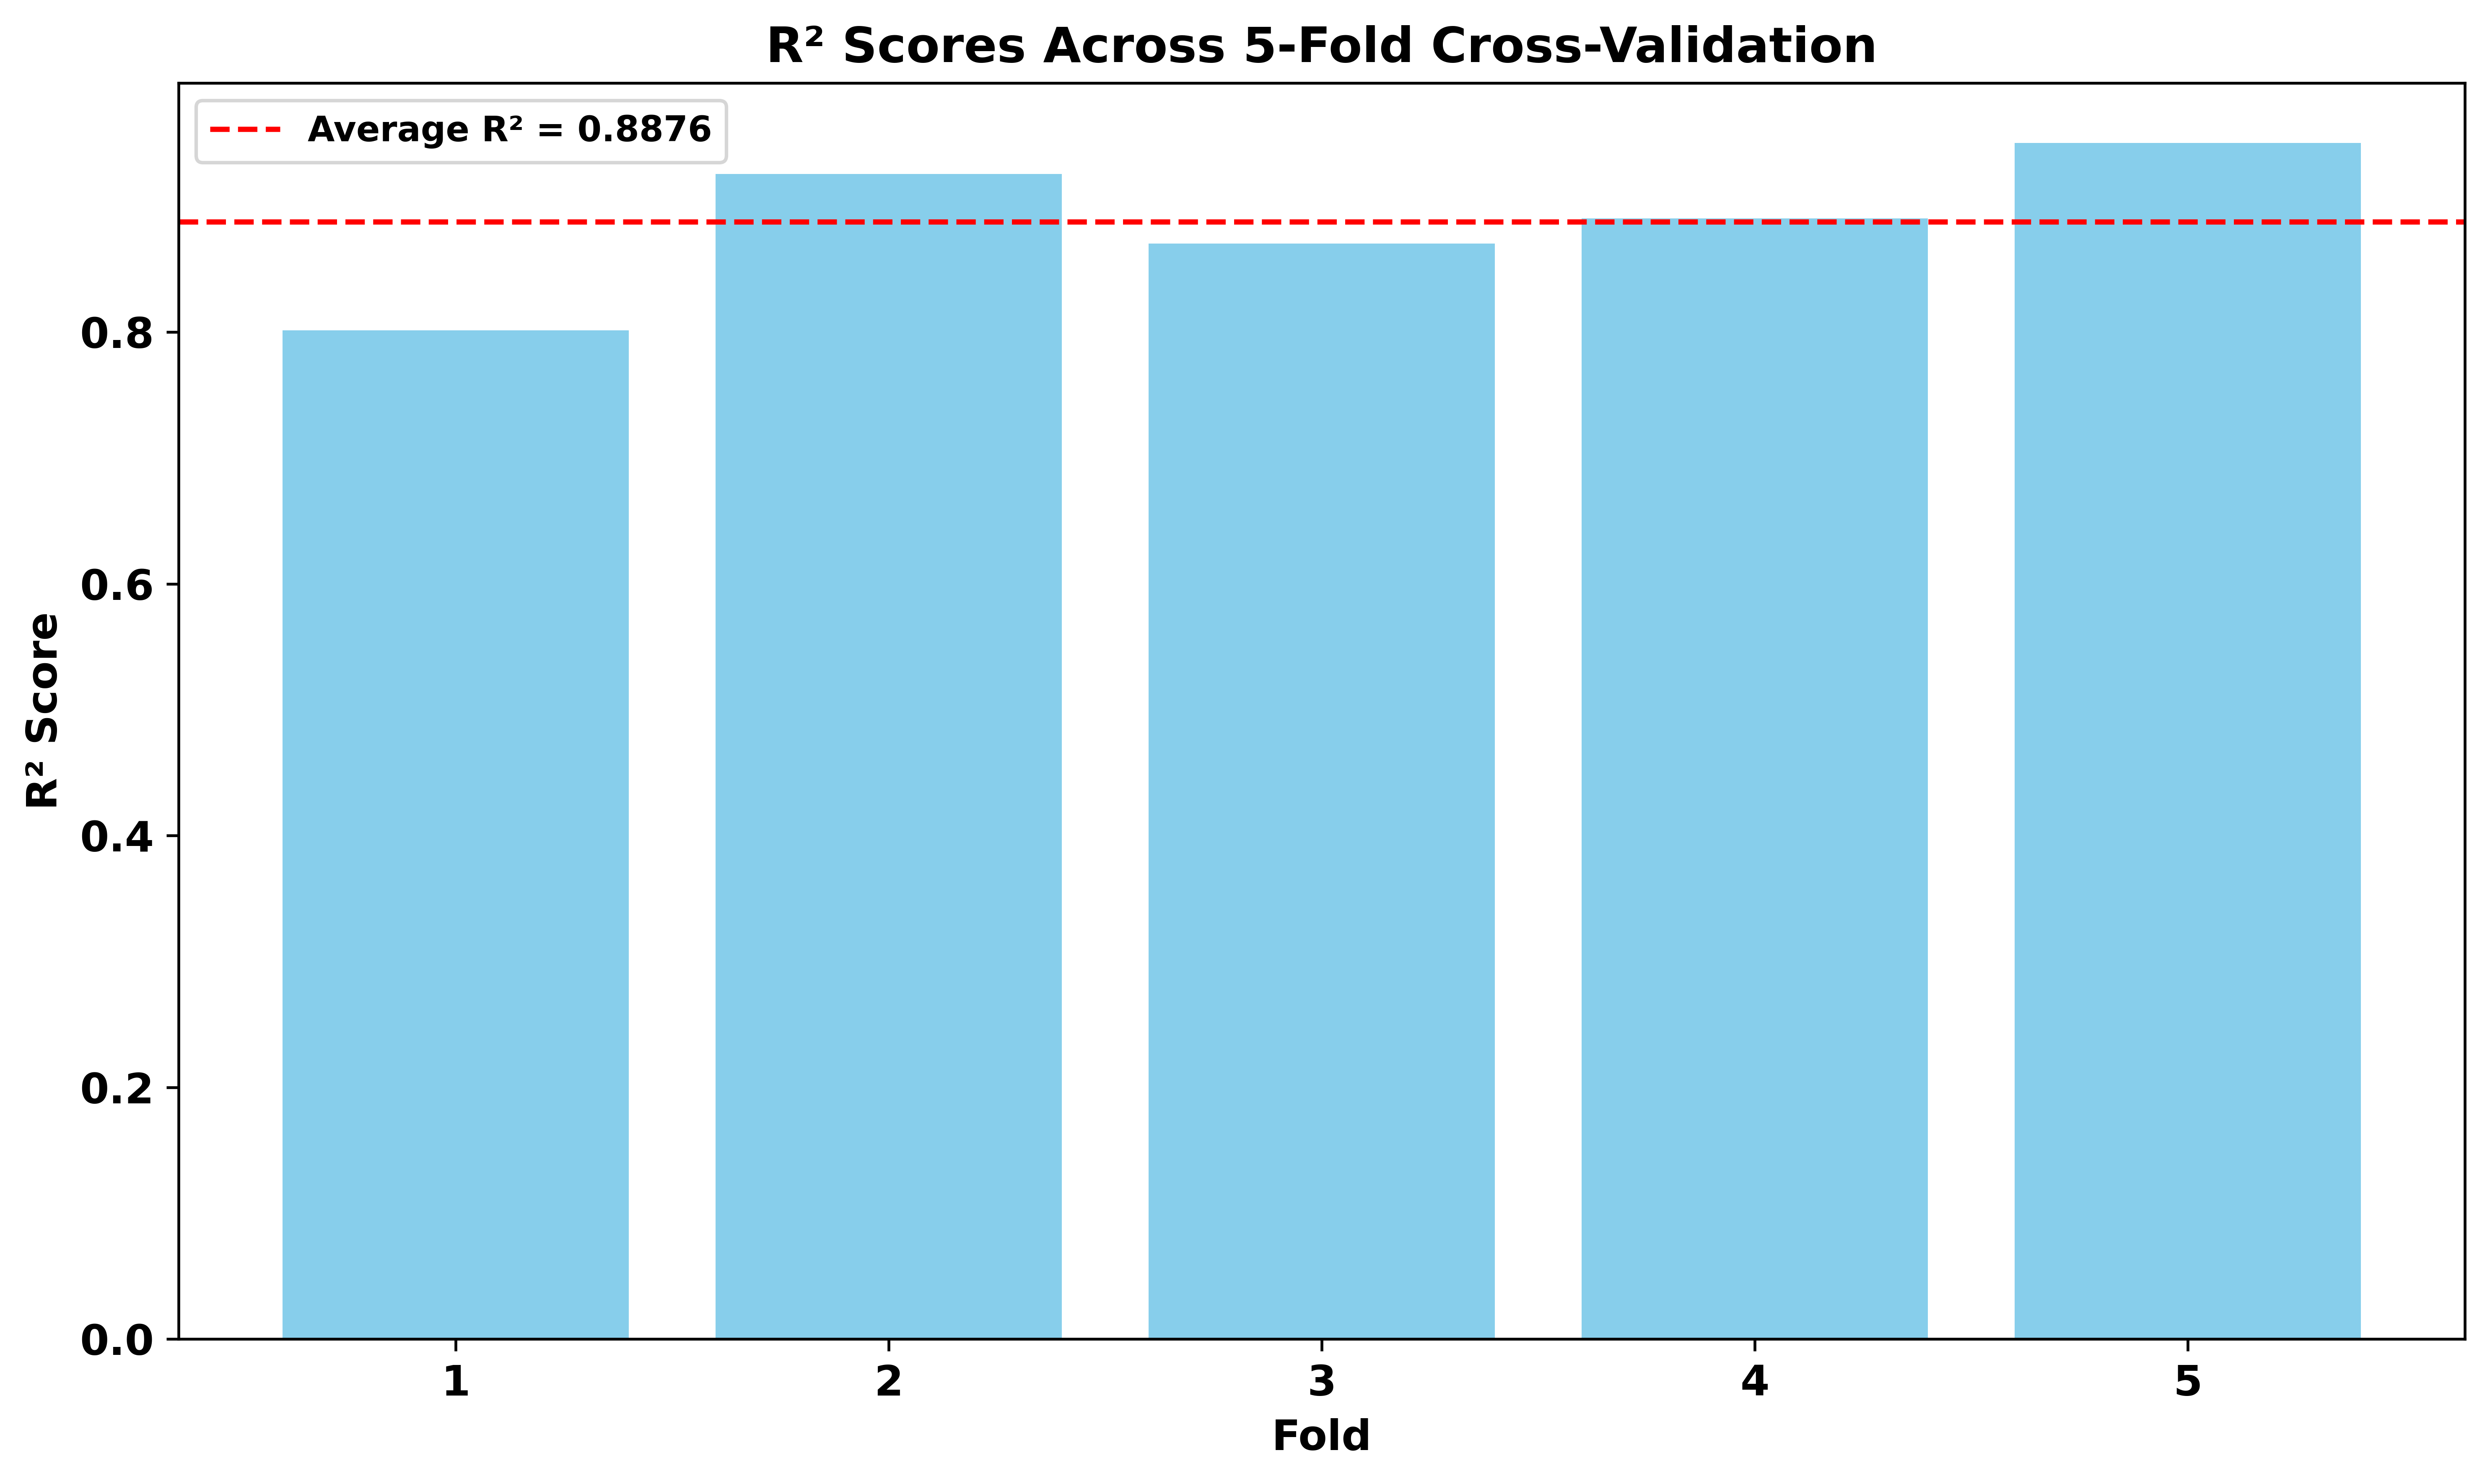

In [76]:
# 5-fold Cross-Validation on Training Set
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
 
# IMPORTANT: define the best model parameters from grid search
best_model = RandomForestRegressor(
    criterion='absolute_error', 
    max_depth=None, 
    n_estimators=100, 
    random_state=42
)
 
# initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
# lists to store metrics for each fold
r2_scores = []
mae_scores = []
rmse_scores = []
 
# perform cross-validation
fold = 1
for train_index, val_index in kf.split(X_train):
 
    # split data
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    best_model.fit(X_train_fold, y_train_fold)
    y_val_pred = best_model.predict(X_val_fold)
    # Calculate metrics
    r2 = r2_score(y_val_fold, y_val_pred)
    mae = mean_absolute_error(y_val_fold, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
    # store metrics here
    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    # print the fold results
    print(f"Fold {fold}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print("-" * 30)
    fold += 1
 
# calculate and print average metrics
avg_r2 = np.mean(r2_scores)
avg_mae = np.mean(mae_scores)
avg_rmse = np.mean(rmse_scores)
std_r2 = np.std(r2_scores)
std_mae = np.std(mae_scores)
std_rmse = np.std(rmse_scores)
 
print("Cross-Validation Results (5-fold):")
print(f"Average R² Score: {avg_r2:.4f} ± {std_r2:.4f}")
print(f"Average MAE: {avg_mae:.4f} ± {std_mae:.4f}")
print(f"Average RMSE: {avg_rmse:.4f} ± {std_rmse:.4f}")
 
# plot the results for all model iterations
plt.figure(figsize=(10, 6), dpi=600)
plt.bar(range(1, 6), r2_scores, color='skyblue')
plt.axhline(y=avg_r2, color='red', linestyle='--', label=f'Average R² = {avg_r2:.4f}')
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('R² Score', fontweight='bold')
plt.title('R² Scores Across 5-Fold Cross-Validation', fontweight='bold')
plt.xticks(range(1, 6), fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout()
plt.savefig('cv_r2_scores.png', dpi=600, bbox_inches='tight')
plt.show()

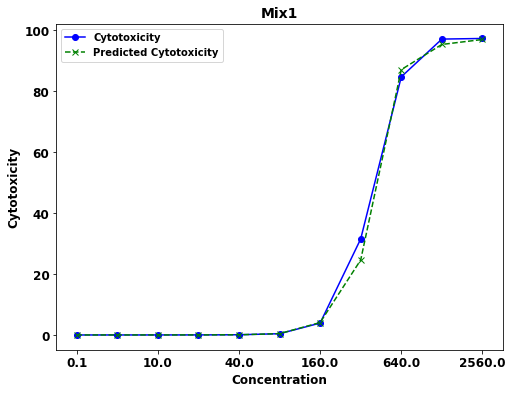

In [87]:
import matplotlib.pyplot as plt
import matplotlib as mpl
 
# Set global font properties to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
 
# Example of improved plot function
def plot_compound(compound_name, dataframe):
    df = dataframe[dataframe["Compound"] == compound_name]
    # Plotting with improved settings
    fig, ax = plt.subplots(figsize=(8,6))
    # Plot data
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, 
             color='blue', marker='o', linestyle='-', label='Cytotoxicity')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, 
             color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')
    # Set title and labels with bold font
    plt.title(compound_name, fontweight='bold', fontsize=14)
    plt.xlabel('Concentration', fontweight='bold', fontsize=12)
    plt.ylabel('Cytotoxicity', fontweight='bold', fontsize=12)
    # Reduce x-axis ticks by showing fewer ticks
    # Get all x-tick positions
    all_xticks = [str(i*1000000) for i in df.Concentration]
    # Show only every nth tick (adjust n as needed)
    n = 2  # Show every 2nd tick
    plt.xticks(all_xticks[::n], all_xticks[::n], fontweight='bold')
    # Make y-ticks bold too
    plt.yticks(fontweight='bold')
    plt.legend(prop={'weight':'bold'})
    # Save with 600 dpi
    plt.savefig(f"{compound_name}_manuscript.png", dpi=600, bbox_inches='tight')
    plt.show()
 
# here is the function call for a specific compound
plot_compound(compound_name = "Mix1", dataframe = altogether)

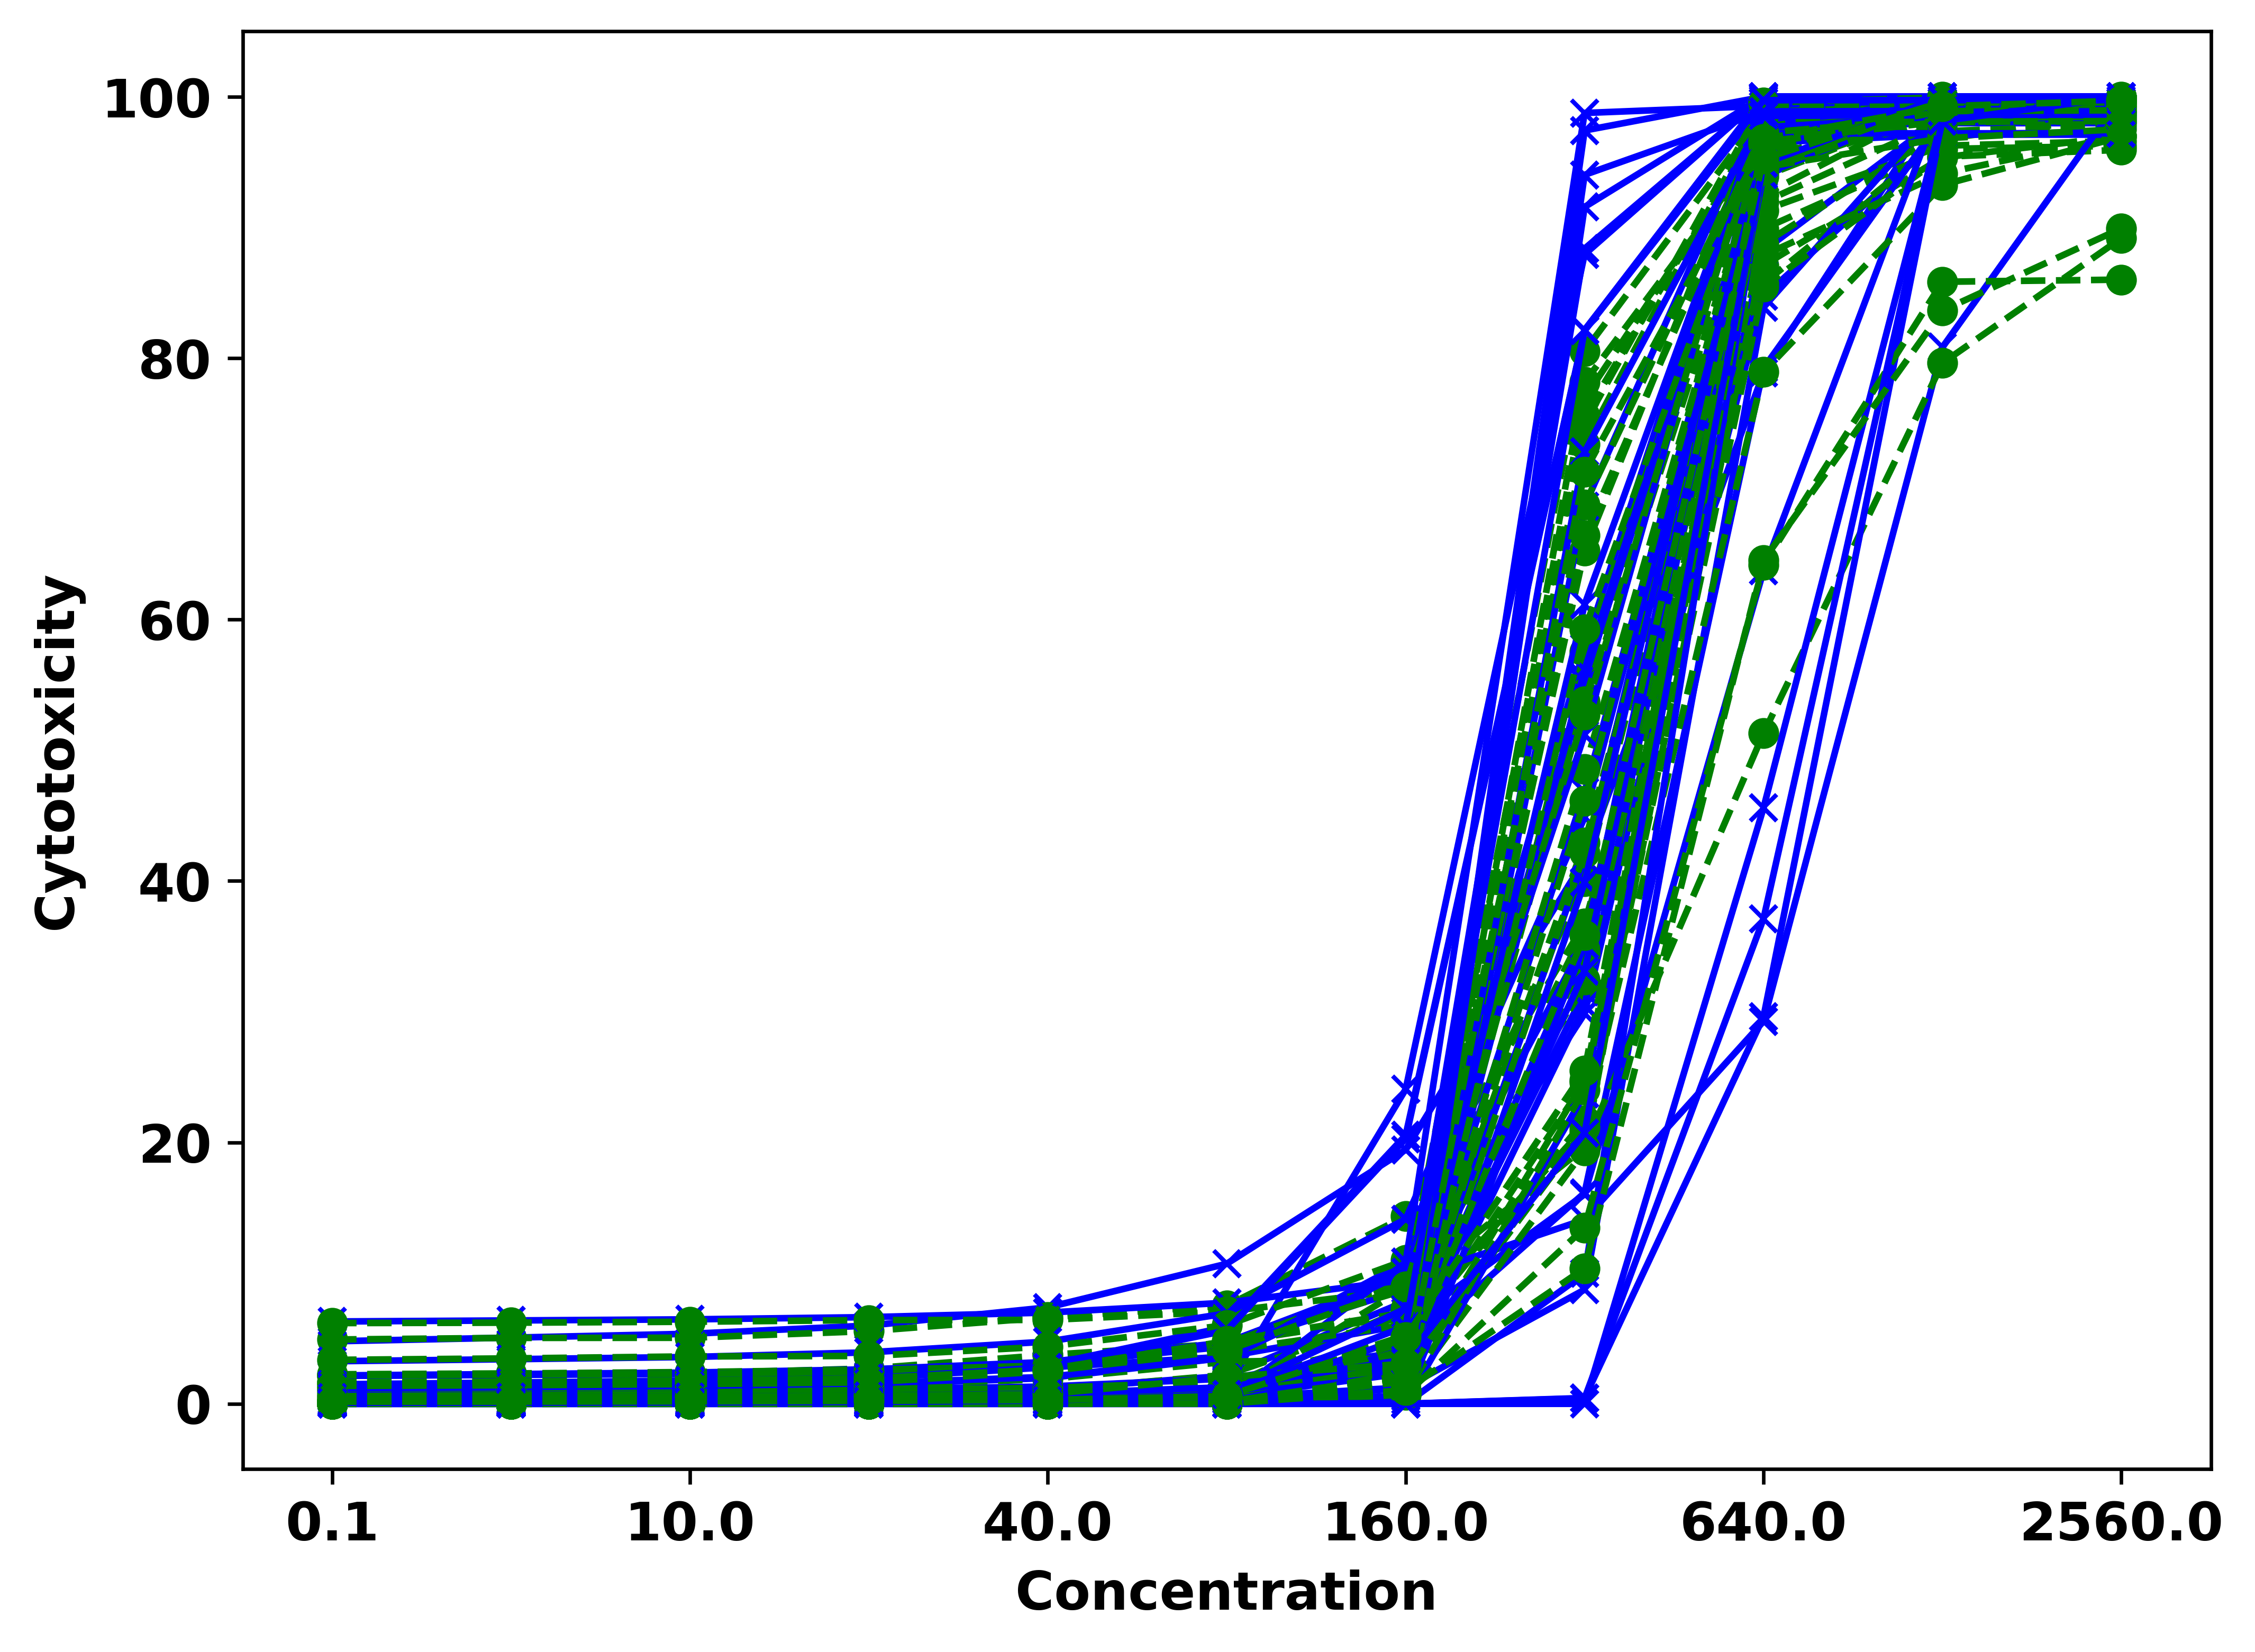

In [61]:
import matplotlib.pyplot as plt

mix_only = altogether[altogether['Compound'].str.contains('Mix')]

#compound_name = "Mix1"

#df = testing_set[testing_set["Compound"] == compound_name]
#concentration = df["Concentration"]

# Set global font properties to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Plotting
fig, ax = plt.subplots(figsize=(8,6), dpi=600)
#plt.figure(figsize=(6,5))

for compound_name in mix_only.Compound.unique():
    
    df = mix_only[mix_only["Compound"] == compound_name]
    
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='x', linestyle='-')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='o', linestyle='--')
    
    
#plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='o', linestyle='-', label='Cytotoxicity')
#plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')

#plt.title(compound_name)
#plt.title(compound_name)
all_xticks = [str(i*1000000) for i in df.Concentration]
plt.xticks(all_xticks[::2], all_xticks[::2], fontweight='bold')

plt.xlabel('Concentration')
plt.ylabel('Cytotoxicity')
#plt.legend()
plt.savefig("manu_figs/mixtures_only.png", dpi=600, bbox_inches='tight')
plt.show()

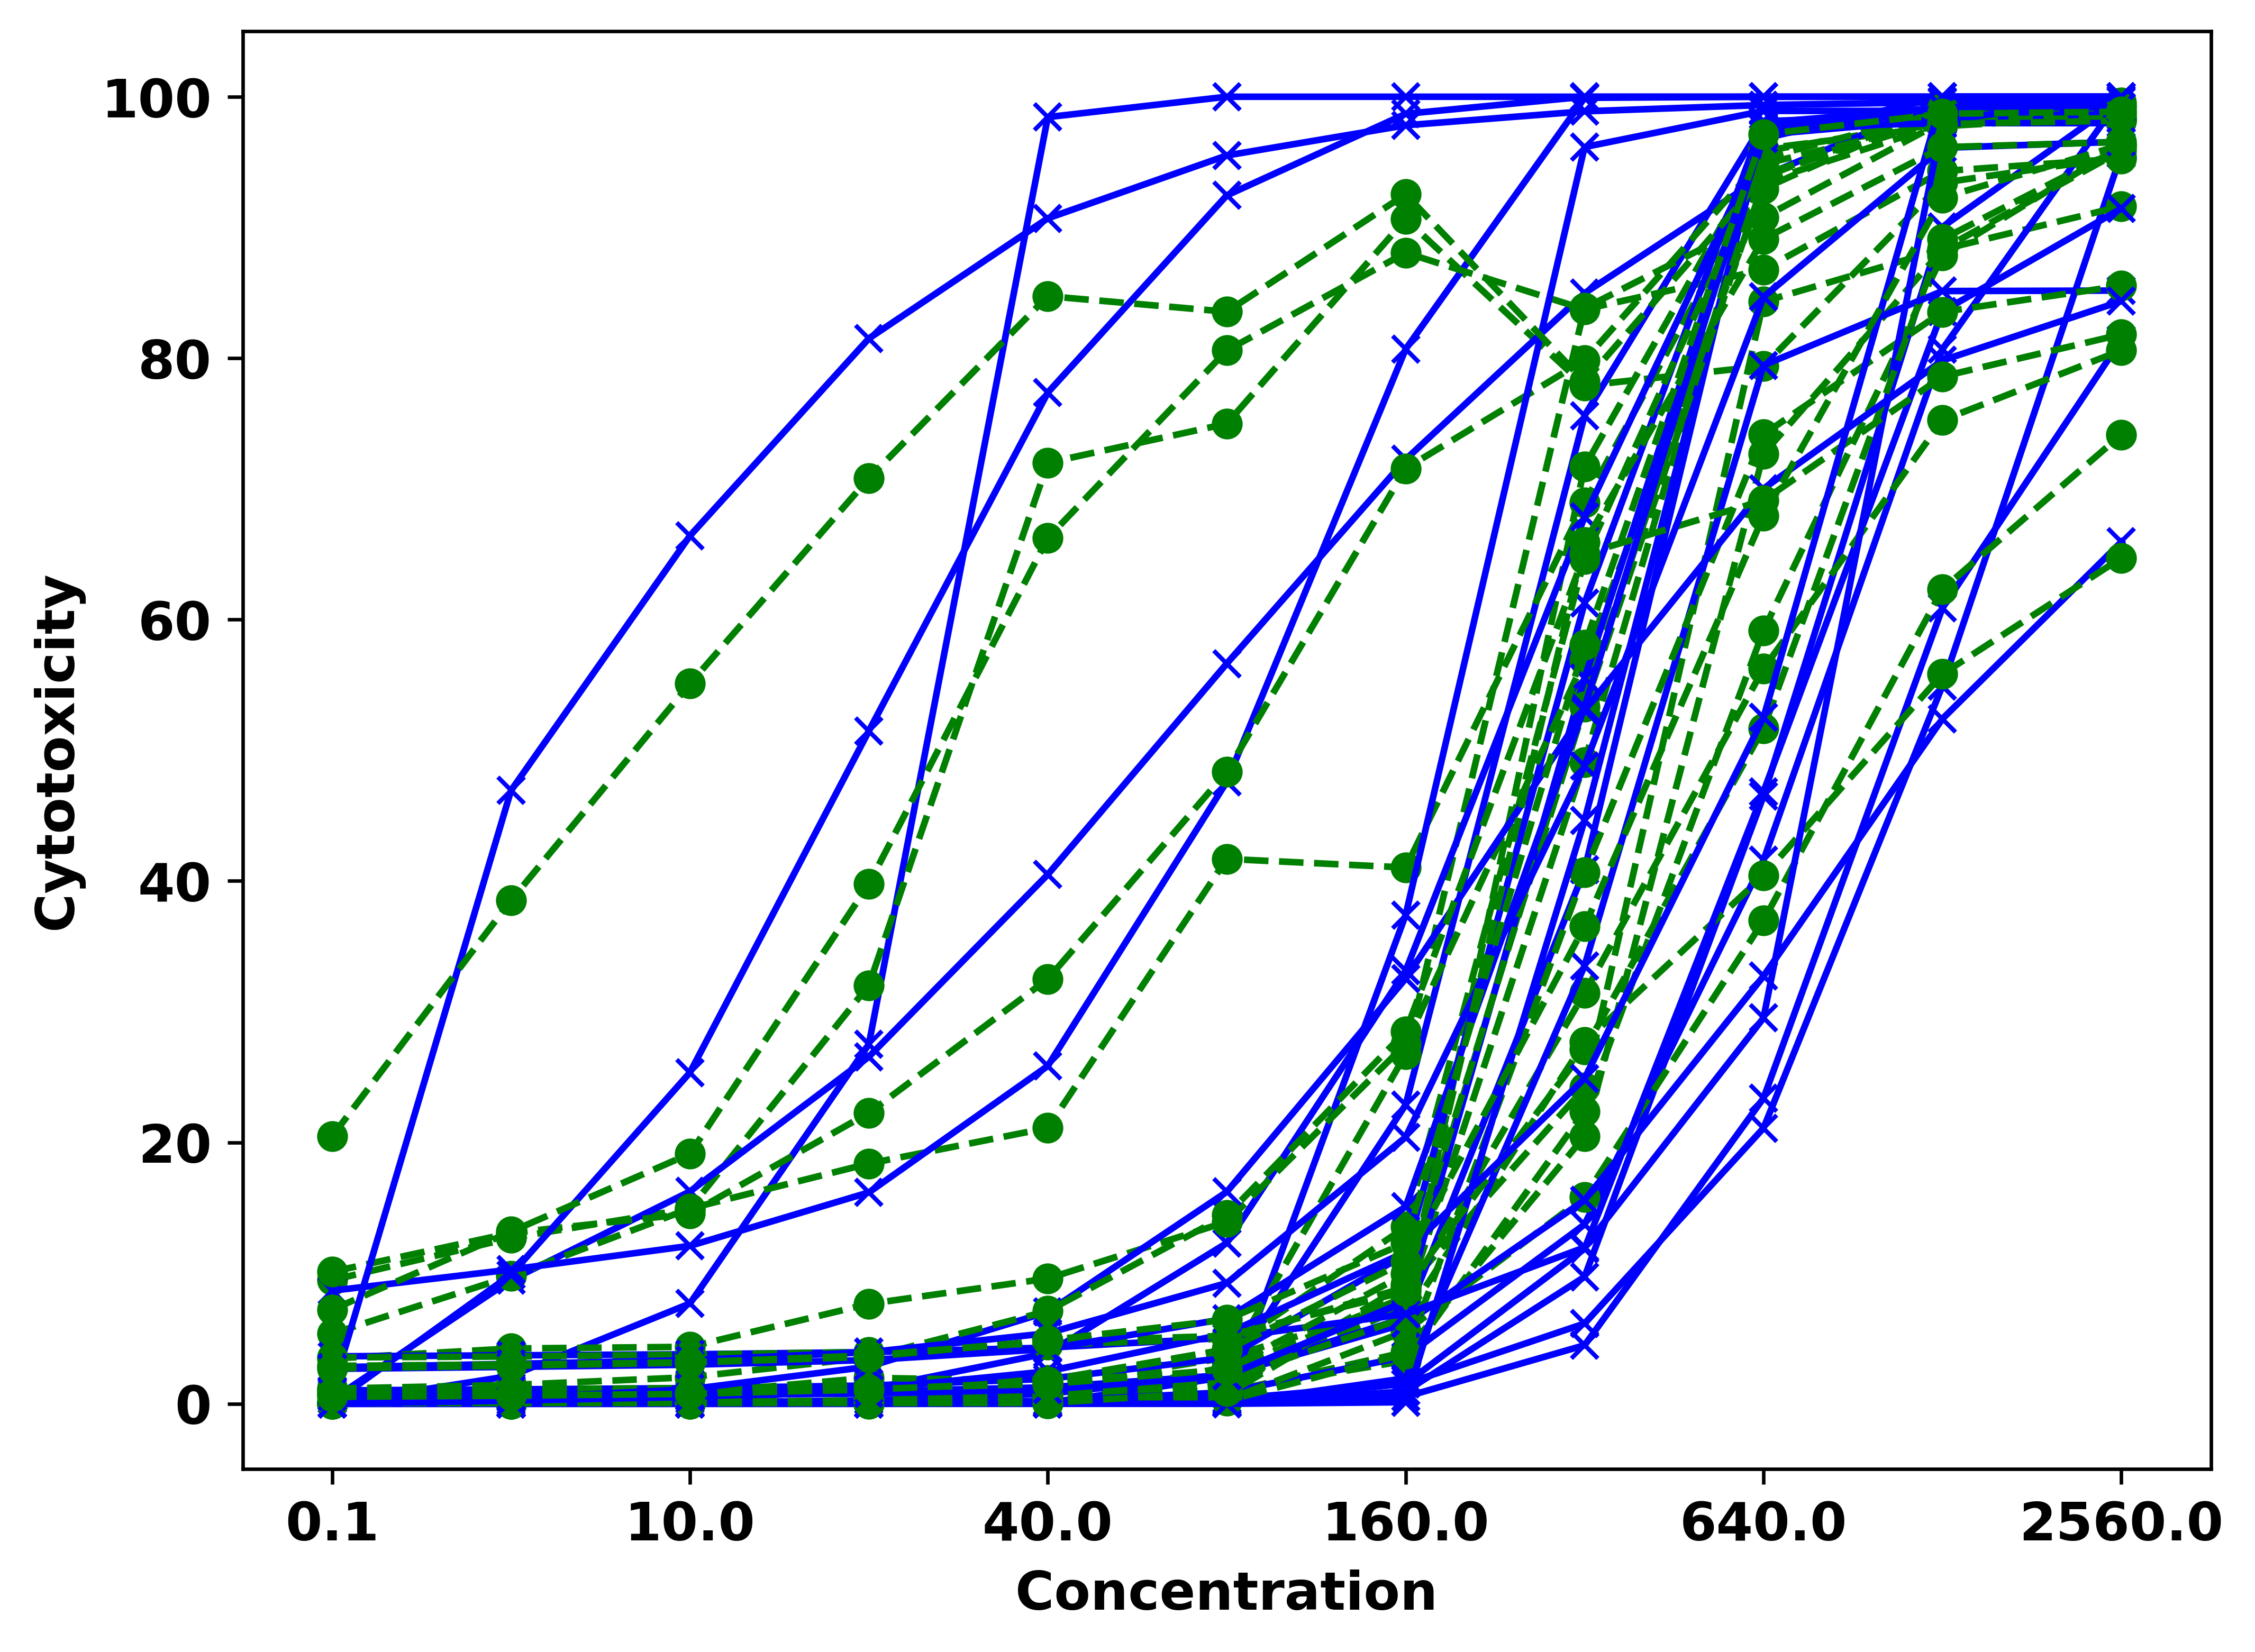

In [45]:
import matplotlib.pyplot as plt

mix_only = altogether[~altogether['Compound'].str.contains('Mix')]

#compound_name = "Mix1"

#df = testing_set[testing_set["Compound"] == compound_name]
#concentration = df["Concentration"]

# Set global font properties to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Plotting
fig, ax = plt.subplots(figsize=(8,6), dpi=600)
#plt.figure(figsize=(6,5))

for compound_name in mix_only.Compound.unique():
    
    df = mix_only[mix_only["Compound"] == compound_name]
    
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='x', linestyle='-')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='o', linestyle='--')
    
    
#plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='o', linestyle='-', label='Cytotoxicity')
#plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')

#plt.title(compound_name)
#plt.title(compound_name)
all_xticks = [str(i*1000000) for i in df.Concentration]
plt.xticks(all_xticks[::2], all_xticks[::2], fontweight='bold')

plt.xlabel('Concentration')
plt.ylabel('Cytotoxicity')
#plt.legend()
plt.savefig("manu_figs/singles_only.png", dpi=600, bbox_inches='tight')
plt.show()

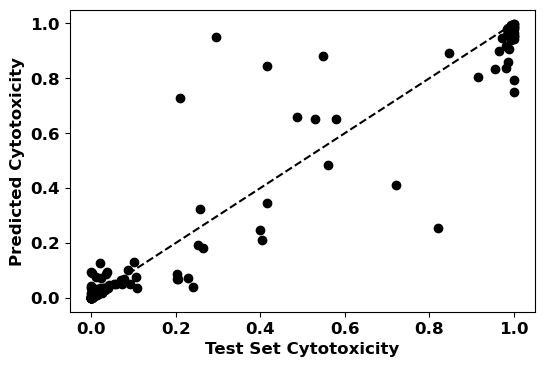

In [64]:
import matplotlib.pyplot as plt
 
# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)
#plt.figure(figsize=(6,5))
 
plt.scatter(y_test,y_pred, color='black', marker='o', label='Cytotoxicity')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Ideal Prediction')
 
plt.xlabel('Test Set Cytotoxicity',fontweight='bold', fontsize=12)
plt.ylabel('Predicted Cytotoxicity',fontweight='bold', fontsize=12)
 
# Make x and y-ticks bold
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.yticks(fontweight='bold')
plt.xticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})
 
#plt.legend()
plt.savefig("ME_RF_Test_Pred.png", dpi=600, bbox_inches='tight')
plt.show()

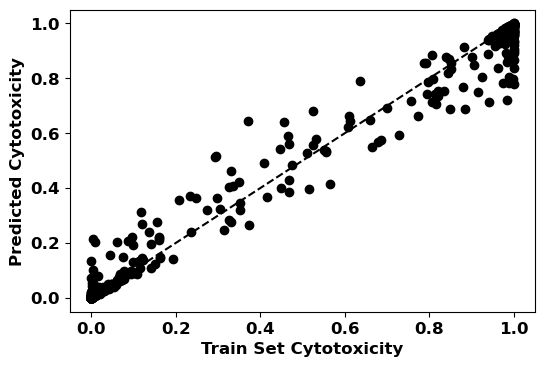

In [73]:
import matplotlib.pyplot as plt

#compound_name = "Mix5"

#df = altogether[altogether["Compound"] == compound_name]
#concentration = df["Concentration"]

# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)
#plt.figure(figsize=(6,5))
plt.scatter(y_train,train_predicted, color='black', marker='o', label='Cytotoxicity')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Ideal Prediction')


plt.xlabel('Train Set Cytotoxicity',fontweight='bold', fontsize=12)
plt.ylabel('Predicted Cytotoxicity',fontweight='bold', fontsize=12)

# Make x and y-ticks bold
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.yticks(fontweight='bold')
plt.xticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})

#plt.legend()
plt.savefig("manu_figs/ME_RF_Train_Pred.png", dpi=600, bbox_inches='tight')
plt.show()

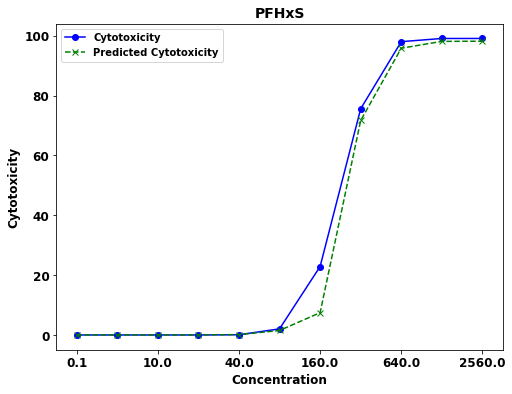

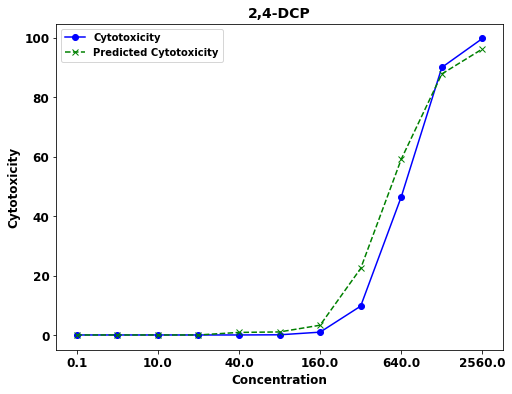

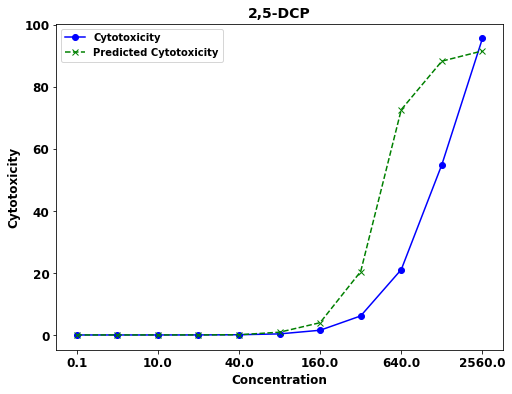

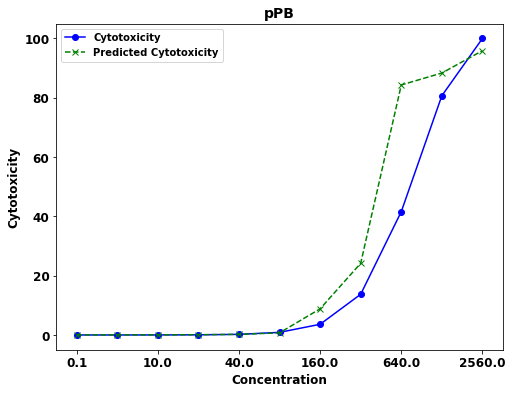

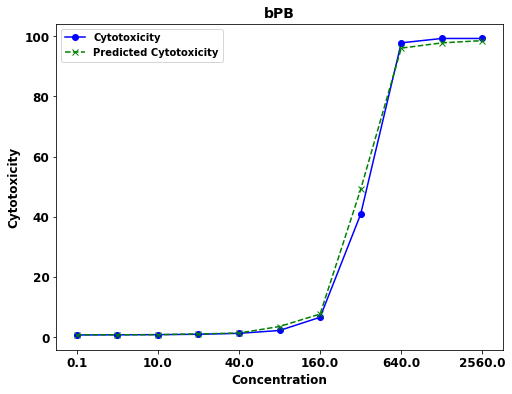

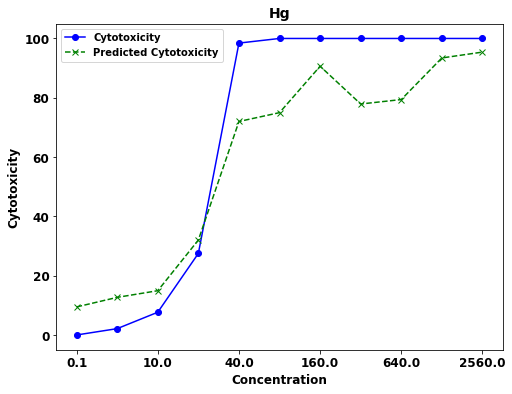

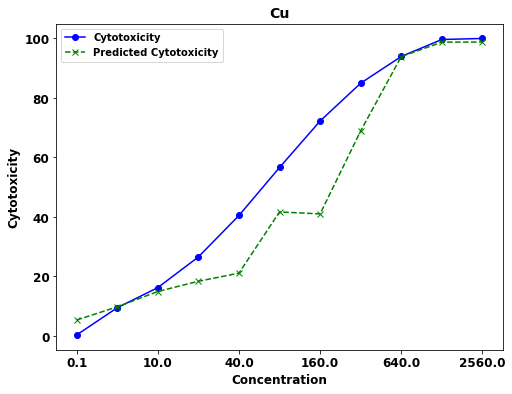

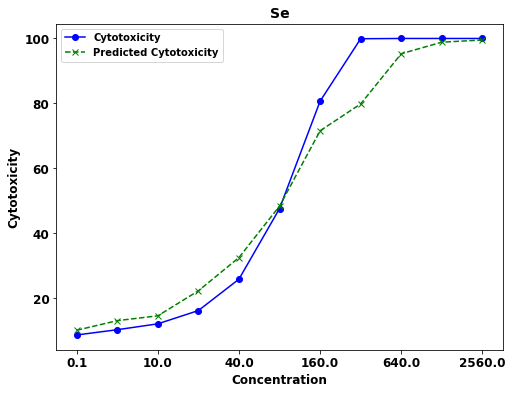

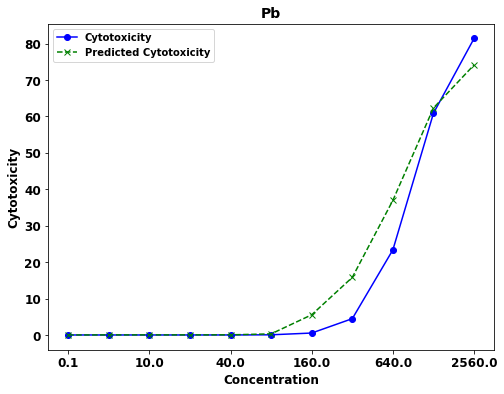

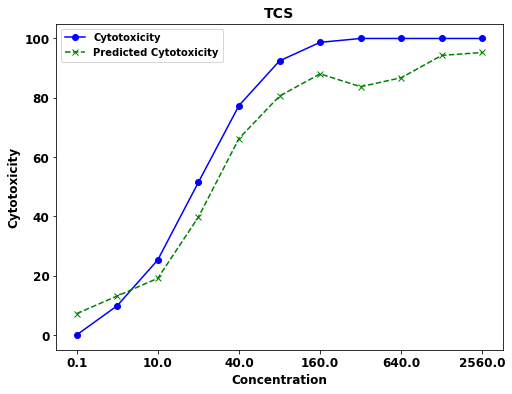

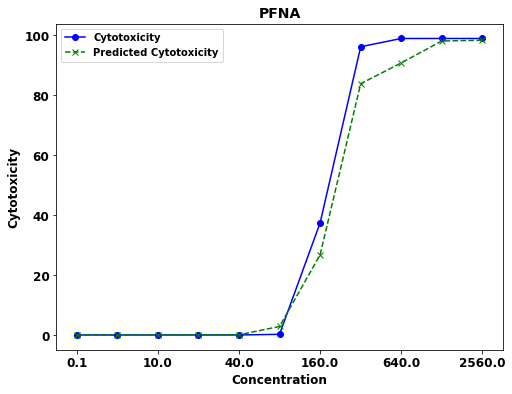

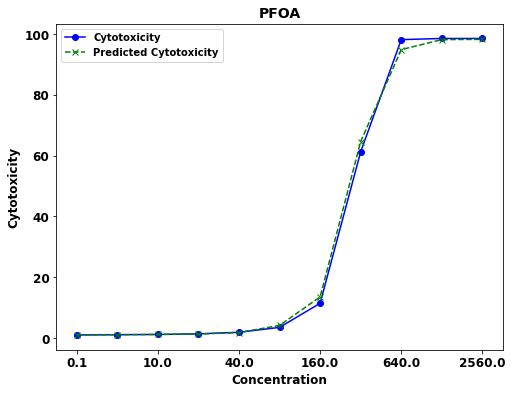

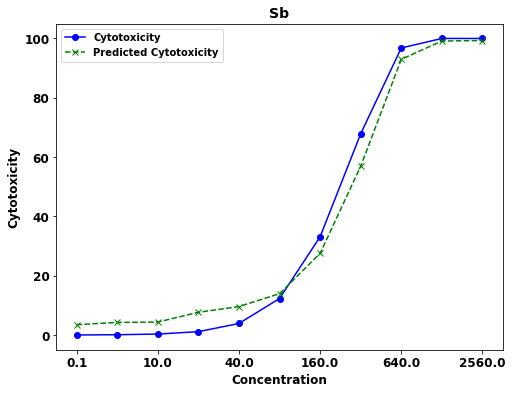

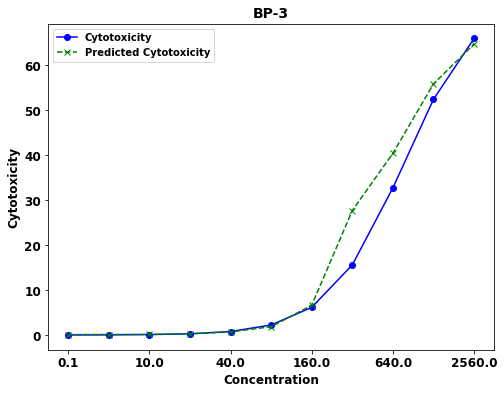

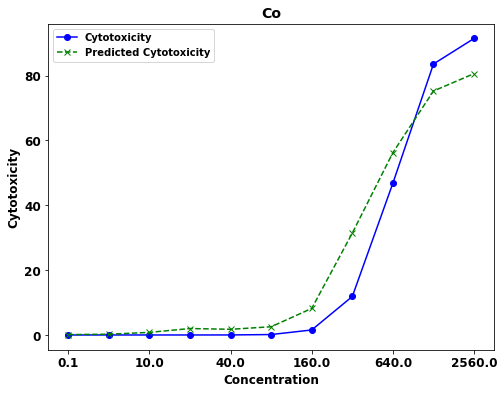

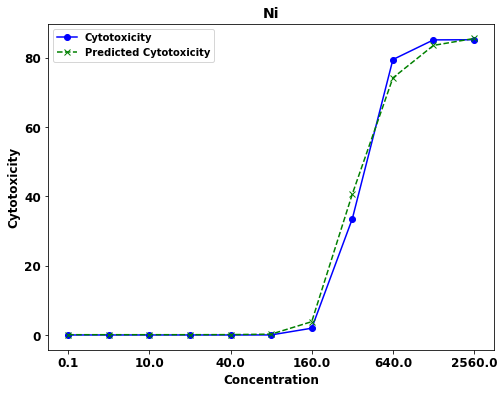

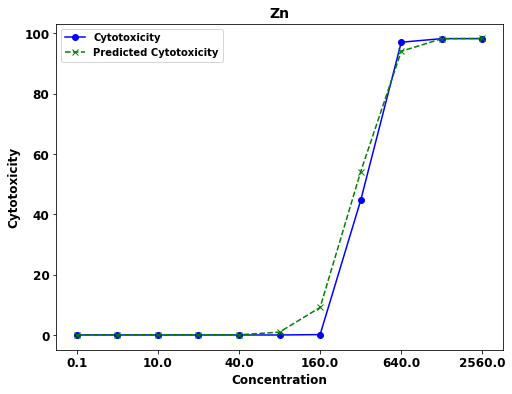

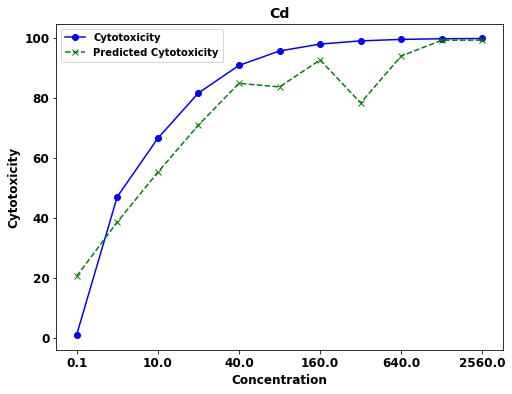

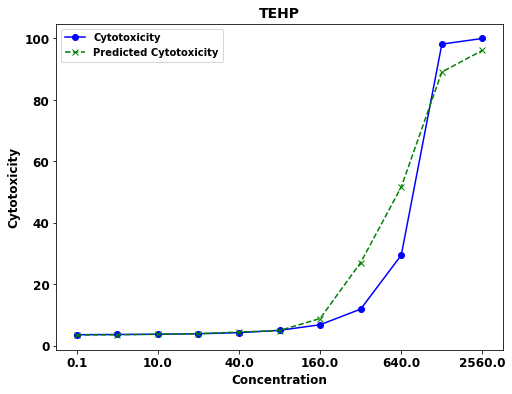

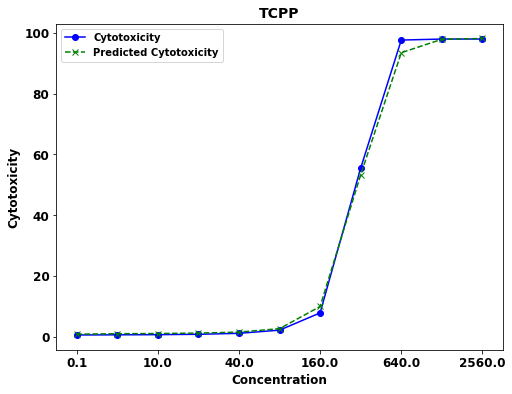

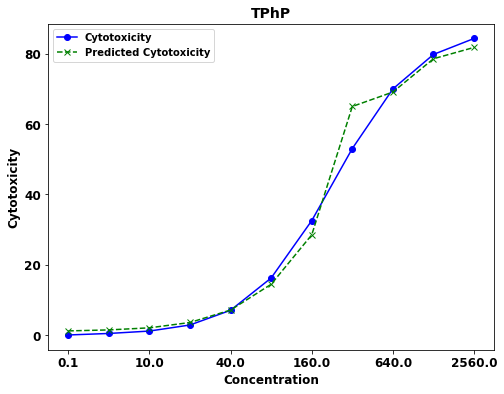

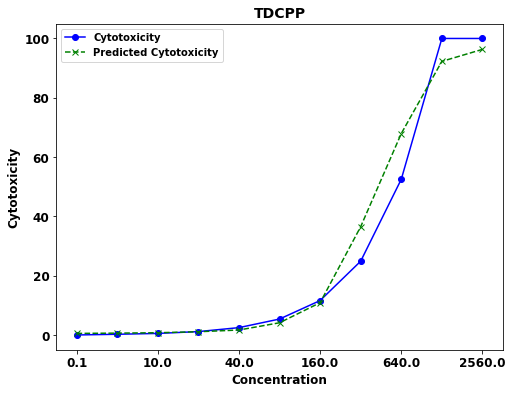

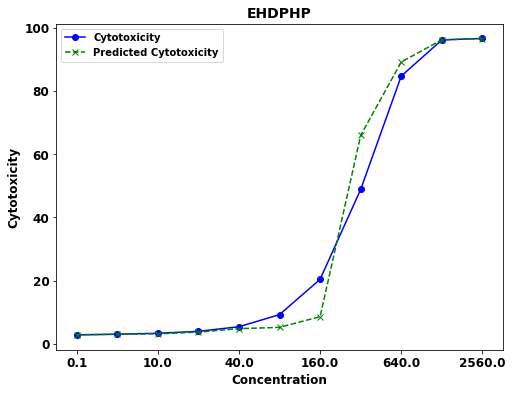

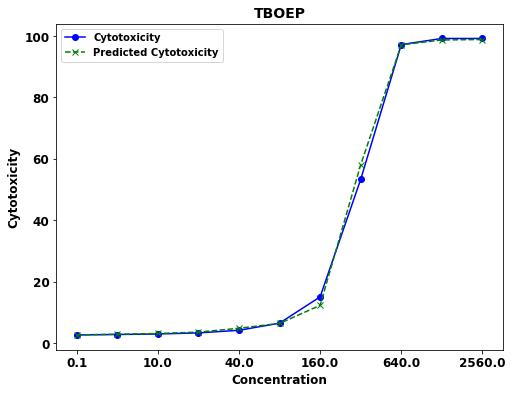

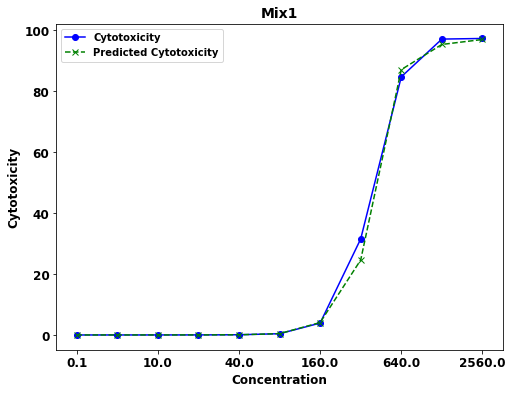

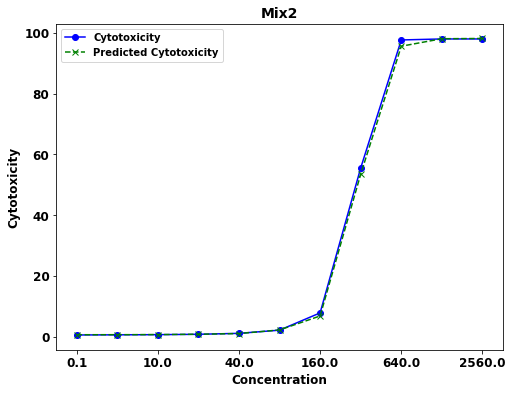

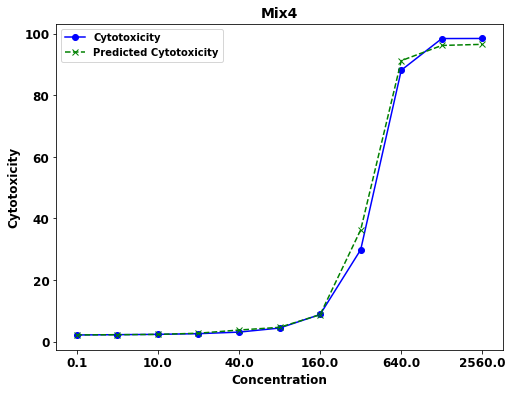

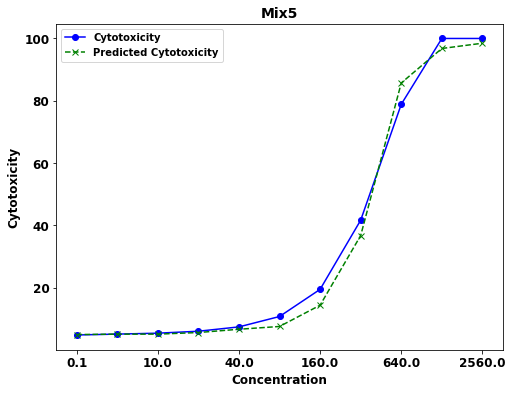

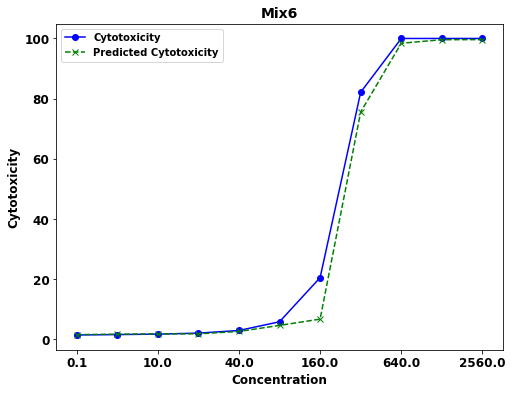

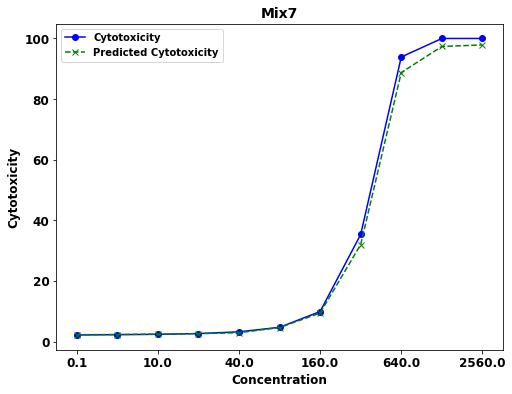

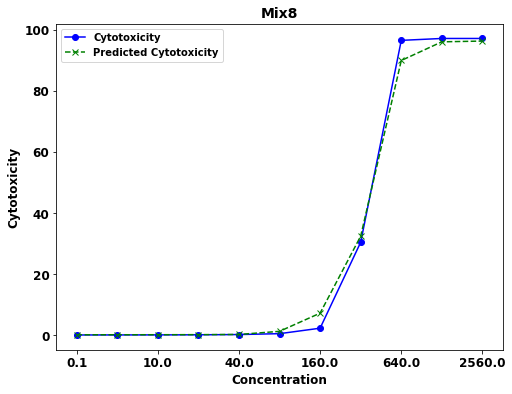

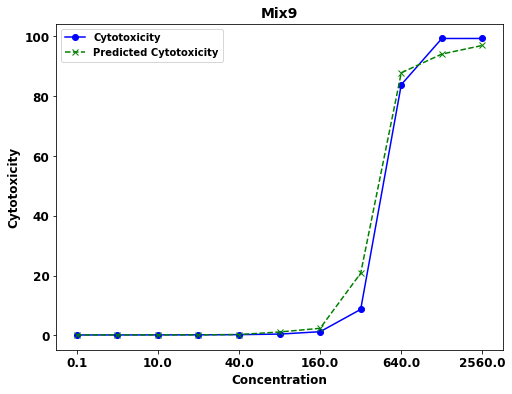

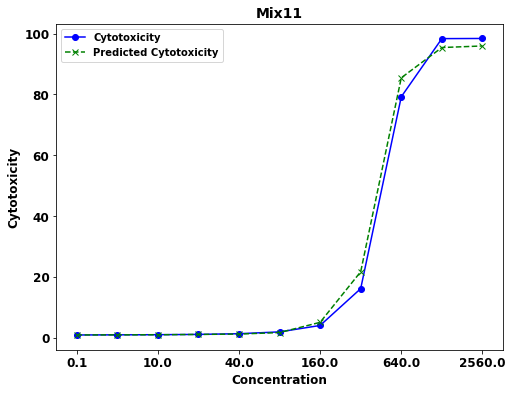

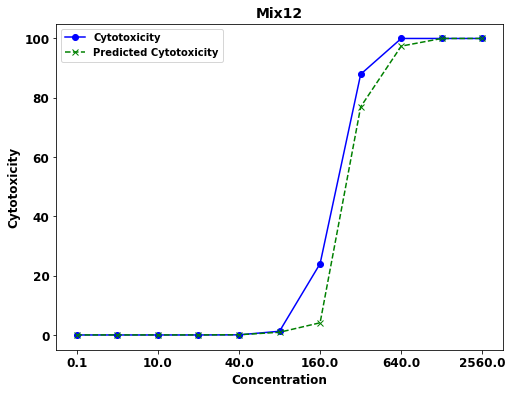

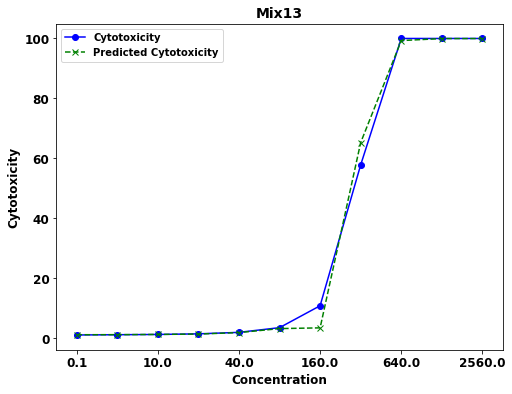

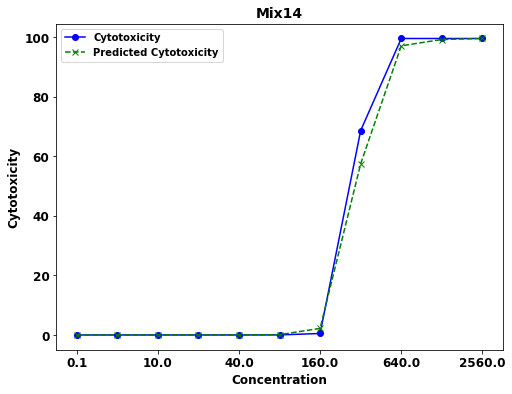

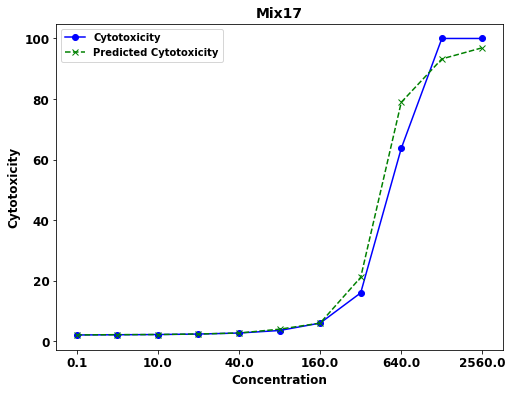

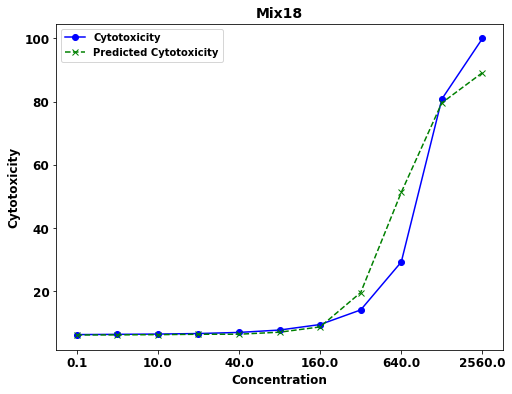

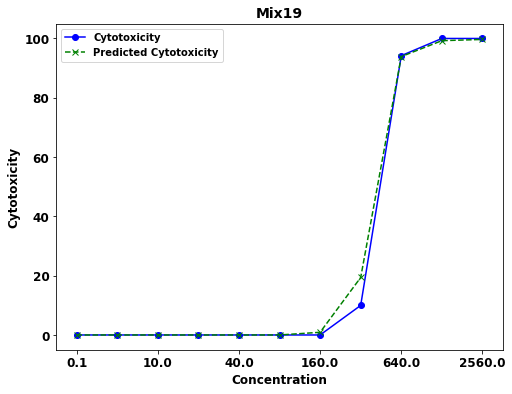

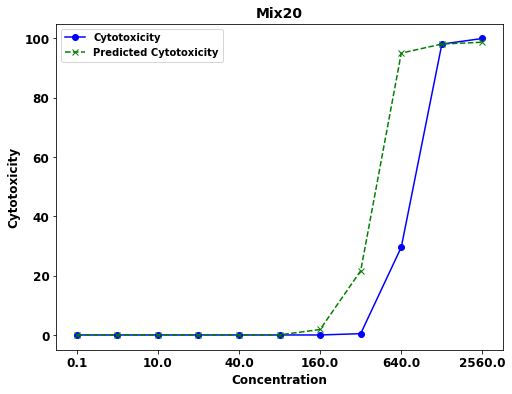

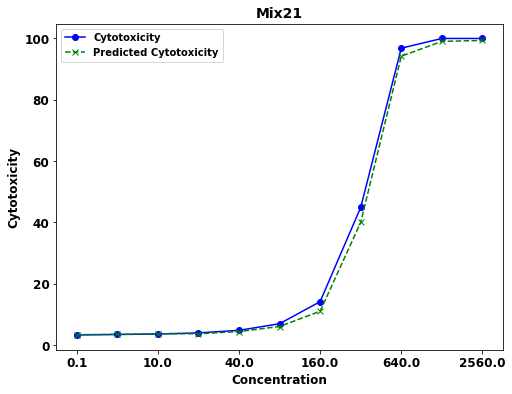

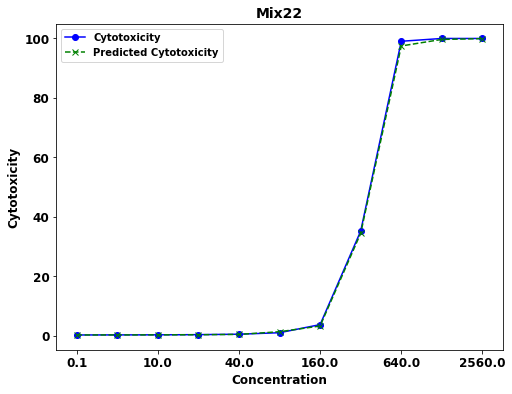

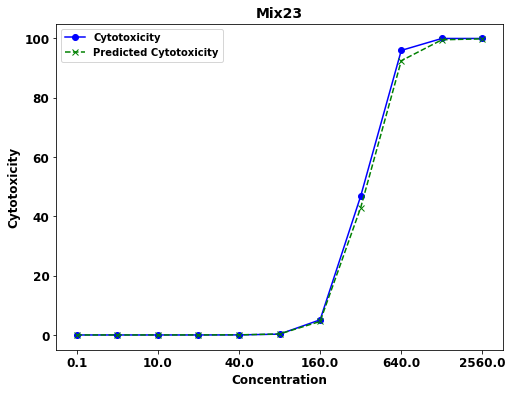

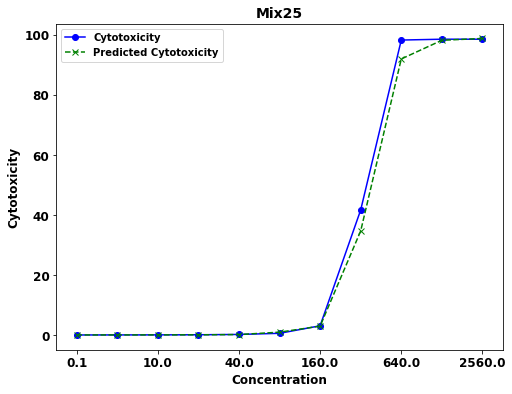

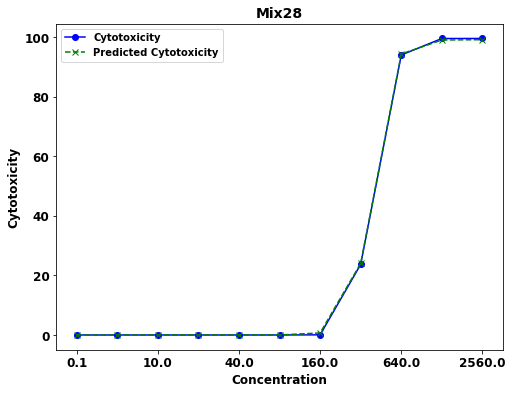

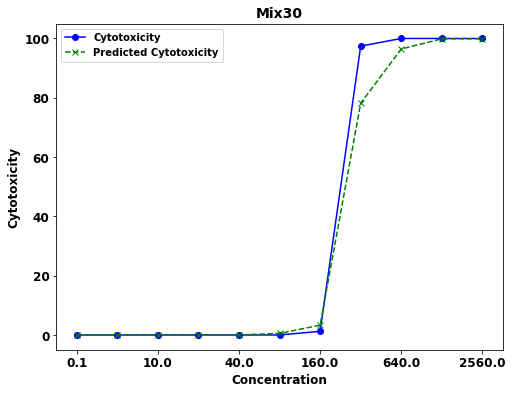

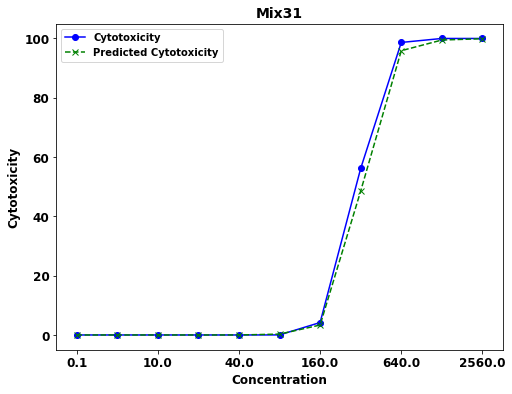

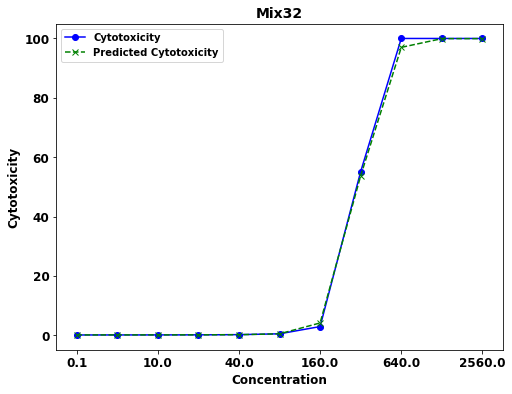

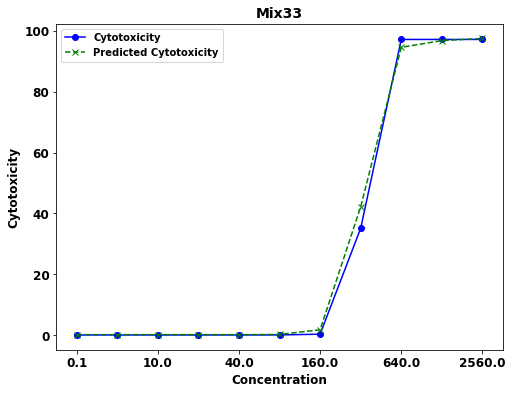

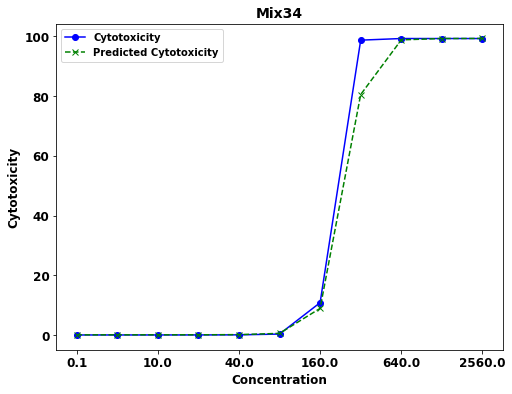

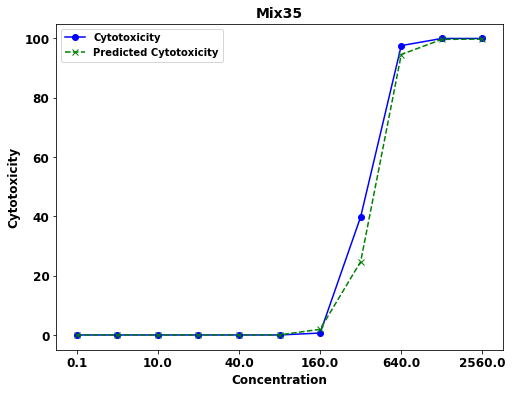

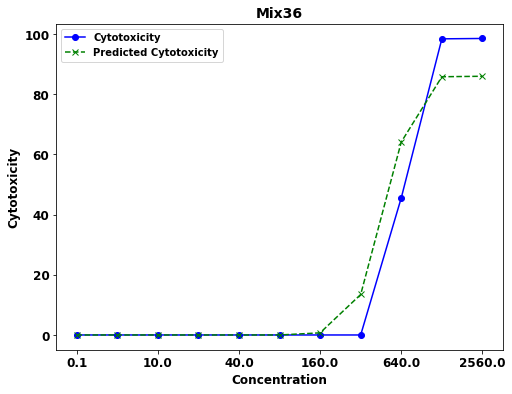

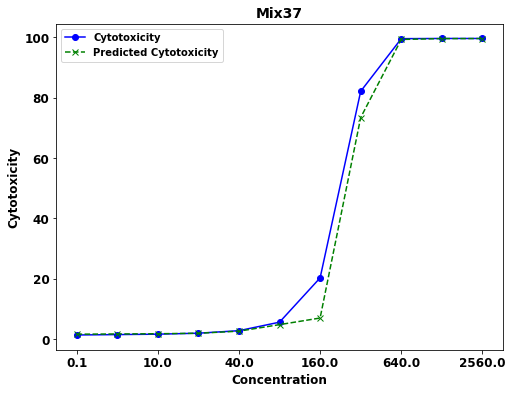

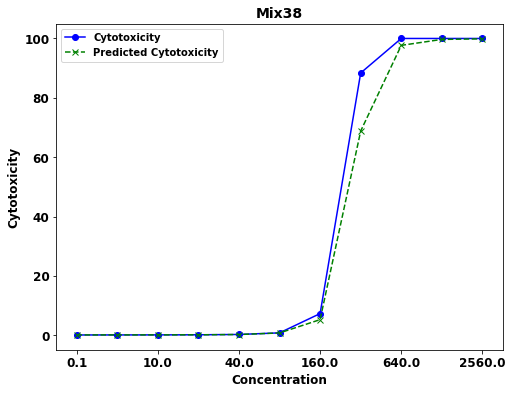

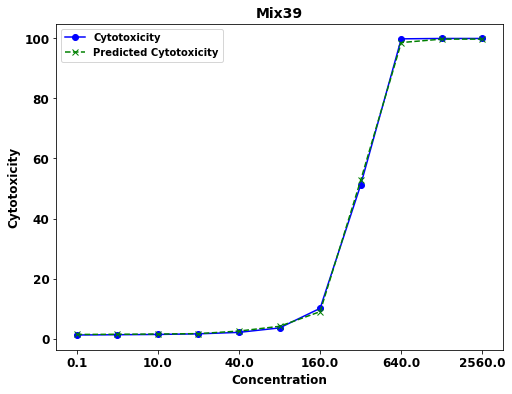

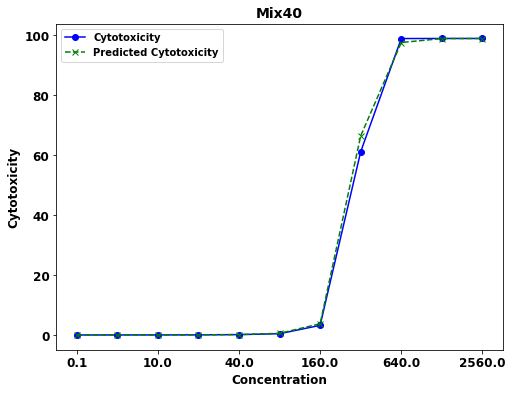

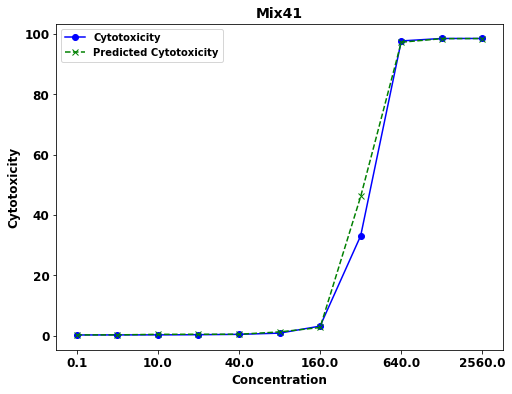

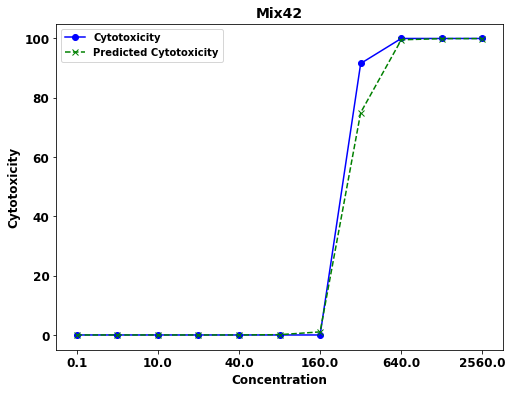

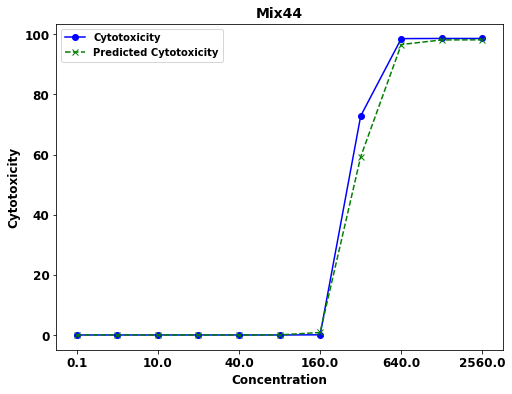

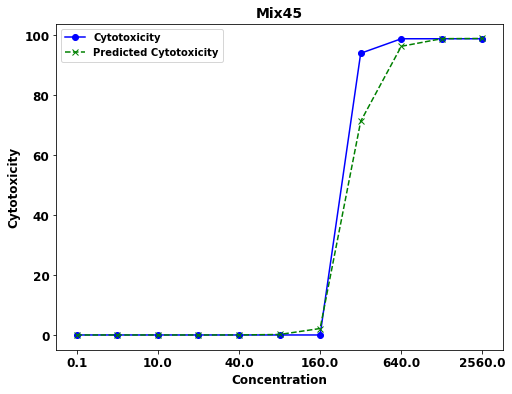

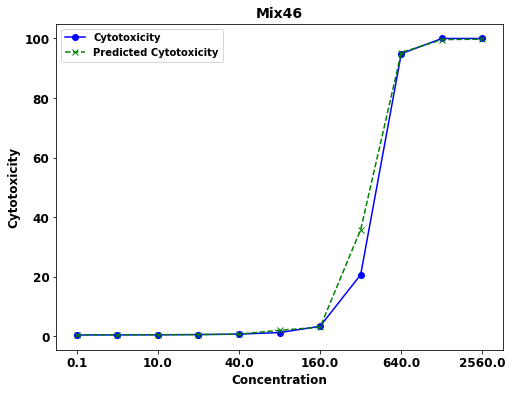

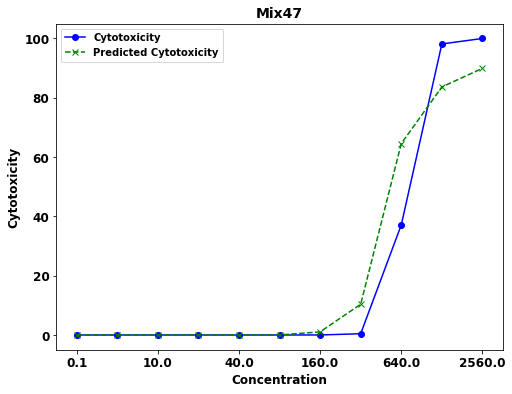

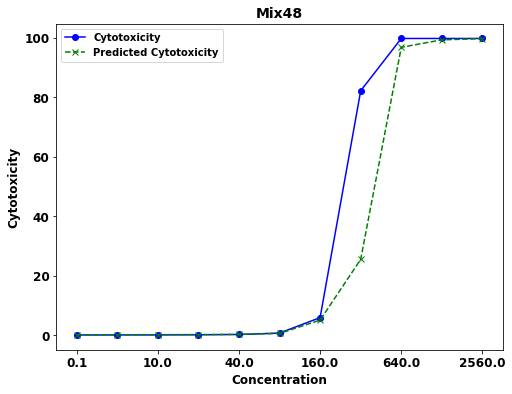

In [74]:
for i in altogether.Compound.unique():
    plot_compound(compound_name = i, dataframe = altogether)